# PDB Homology-Leakage Re-Benchmark (10-seed, Drive-persistent & resumable)

**Runtime → Change runtime type → GPU (T4 is enough).**

All outputs are written to your Google Drive at
`/content/drive/MyDrive/Colab Notebooks/pdb_data/work/`, so if Colab disconnects
you can just re-run from the top: every expensive cell **skips work already on Drive**
- dataset build / MMseqs2 clustering: skipped if their CSV exists
- ESM-2 embeddings: checkpointed every few thousand sequences and resumed
- 10-seed ablation: each `(seed, split, model)` result is appended to Drive as it
  completes; a re-run skips everything already recorded and continues where it stopped

Raw inputs (`pdb_data_seq.csv`, `pdb_data_no_dups.csv`) are expected in
`/content/drive/MyDrive/Colab Notebooks/pdb_data/`.

## 0 · Setup + mount Drive

In [1]:
!pip install -q -U "transformers>=4.46,<5" "tokenizers>=0.20" xgboost
import os, torch
from google.colab import drive
drive.mount('/content/drive')

DRIVE = "/content/drive/MyDrive/Colab Notebooks/pdb_data"   # raw CSVs live here
W     = f"{DRIVE}/work"                                     # all outputs persist here
SCRATCH = "/content/scratch"                                # ephemeral intermediates
os.makedirs(W, exist_ok=True)
os.makedirs(SCRATCH, exist_ok=True)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE — switch runtime to GPU!")
print("persist dir:", W)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 13.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.24.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.
Mounted at /content/drive
GPU: NONE — switch runtime to GPU!
persist dir: /content/drive/MyDrive/Colab Notebooks/pdb_data/work


## 1 · Check raw data on Drive

Expects the two Kaggle CSVs in `DRIVE`. If they are missing you can upload them here
(they will be copied to Drive so this only happens once).

In [2]:
need = ["pdb_data_seq.csv", "pdb_data_no_dups.csv"]
missing = [f for f in need if not os.path.exists(f"{DRIVE}/{f}")]
if not missing:
    print("raw CSVs found in", DRIVE)
else:
    print("missing:", missing, "-> upload now (saved to Drive)")
    from google.colab import files
    up = files.upload()
    for name in up:
        os.replace(name, f"{DRIVE}/{name}")
    print("saved to", DRIVE)

raw CSVs found in /content/drive/MyDrive/Colab Notebooks/pdb_data


## 2 · Build the clean dataset  _(skipped if `dataset.csv` exists)_

Labels come from `pdb_data_no_dups.csv` only; deduplicate identical sequences; drop
conflicting-label sequences and `UNKNOWN FUNCTION` classes.

In [3]:
import pandas as pd
if os.path.exists(f"{W}/dataset.csv"):
    d = pd.read_csv(f"{W}/dataset.csv")
    print(f"[skip] dataset.csv exists -> {len(d):,} sequences")
else:
    TOP_K = 10
    DROP  = {"STRUCTURAL GENOMICS, UNKNOWN FUNCTION", "UNKNOWN FUNCTION"}
    VALID = set("ACDEFGHIKLMNPQRSTVWY")
    seq = pd.read_csv(f"{DRIVE}/pdb_data_seq.csv", low_memory=False).rename(columns={"classification": "macroType"})
    nod = pd.read_csv(f"{DRIVE}/pdb_data_no_dups.csv", low_memory=False)
    df = (seq[seq.macroType == "Protein"][["structureId", "chainId", "sequence"]]
          .merge(nod[["structureId", "classification"]], on="structureId", how="inner")
          .dropna(subset=["sequence", "classification"]))
    print(f"protein chains w/ label         : {len(df):>7,}")
    df["classification"] = df.classification.str.strip().str.upper()
    df = df[~df.classification.isin(DROP)]
    df = df[df.sequence.apply(lambda s: set(s) <= VALID)]
    df["L"] = df.sequence.str.len()
    df = df[(df.L >= 50) & (df.L <= 1000)]
    print(f"canonical-20, len 50-1000       : {len(df):>7,}")
    lab_n = df.groupby("sequence").classification.nunique()
    amb   = set(lab_n[lab_n > 1].index)
    print(f"conflicting-label sequences     : {len(amb):>7,}  (dropped)")
    df = df[~df.sequence.isin(amb)]
    d = df.drop_duplicates(subset=["sequence"]).copy()
    print(f"unique, unambiguous sequences   : {len(d):>7,}")
    top = d.classification.value_counts().head(TOP_K)
    d = d[d.classification.isin(top.index)].reset_index(drop=True)
    d["id"] = [f"s{i}" for i in range(len(d))]
    print(f"\ntop-{TOP_K} classes -> {len(d):,} sequences\n")
    print(top.to_string())
    d.to_csv(f"{W}/dataset.csv", index=False)

[skip] dataset.csv exists -> 40,211 sequences


## 2b · Filtering flow audit — exact counts at every step

The manuscript currently reports "roughly three quarters" of raw chains as duplicates and
"roughly 8%" of unique sequences as multi-label. Reviewers cannot verify the 40,211 endpoint
from approximations. This cell recomputes the full filtering cascade from the raw files and
writes `filtering_flow.csv`, so exact numbers can be pasted into Methods.

Runs independently of Section 2 and does not overwrite `dataset.csv`.


In [4]:
# Recompute exact counts at each filtering step (does NOT rebuild dataset.csv).
import pandas as pd, os

FLOW = f"{W}/filtering_flow.csv"
if os.path.exists(FLOW):
    flow = pd.read_csv(FLOW)
    print(f"[skip] {FLOW} exists")
    print(flow.to_string(index=False))
else:
    TOP_K = 10
    DROP  = {"STRUCTURAL GENOMICS, UNKNOWN FUNCTION", "UNKNOWN FUNCTION"}
    VALID = set("ACDEFGHIKLMNPQRSTVWY")

    seq = pd.read_csv(f"{DRIVE}/pdb_data_seq.csv", low_memory=False).rename(
        columns={"classification": "macroType"})
    nod = pd.read_csv(f"{DRIVE}/pdb_data_no_dups.csv", low_memory=False)

    rows = []
    def step(label, n, note=""):
        rows.append(dict(step=len(rows) + 1, description=label, n_sequences=n, note=note))
        print(f"{len(rows):>2}. {label:<44s} {n:>9,}  {note}")

    step("Raw rows in pdb_data_seq.csv", len(seq))
    s_prot = seq[seq.macroType == "Protein"]
    step("Rows annotated macroType == 'Protein'", len(s_prot))

    df = (s_prot[["structureId", "chainId", "sequence"]]
          .merge(nod[["structureId", "classification"]], on="structureId", how="inner")
          .dropna(subset=["sequence", "classification"]))
    step("Protein chains with a usable label", len(df))

    df["classification"] = df.classification.str.strip().str.upper()
    n_before = len(df)
    df = df[~df.classification.isin(DROP)]
    step("After dropping unknown-function classes", len(df), f"removed {n_before-len(df):,}")

    n_before = len(df)
    df = df[df.sequence.apply(lambda s: set(s) <= VALID)]
    step("Canonical 20 amino acids only", len(df), f"removed {n_before-len(df):,}")

    n_before = len(df)
    df["L"] = df.sequence.str.len()
    df = df[(df.L >= 50) & (df.L <= 1000)]
    step("Length 50-1000 residues", len(df), f"removed {n_before-len(df):,}")

    # --- duplicate accounting (reported BEFORE the multi-label filter) ---
    n_chains = len(df)
    n_unique_all = df.sequence.nunique()
    n_dup_chains = n_chains - n_unique_all
    print(f"\n    duplicate accounting: {n_chains:,} chains -> {n_unique_all:,} distinct sequences")
    print(f"    exact-sequence duplicate chains: {n_dup_chains:,} "
          f"({100*n_dup_chains/n_chains:.1f}% of filtered chains)")

    lab_n = df.groupby("sequence").classification.nunique()
    amb = set(lab_n[lab_n > 1].index)
    print(f"    multi-label distinct sequences : {len(amb):,} "
          f"({100*len(amb)/n_unique_all:.1f}% of distinct sequences)")

    df = df[~df.sequence.isin(amb)]
    step("After removing multi-label sequences", len(df),
         f"{len(amb):,} distinct seqs dropped")

    d_ = df.drop_duplicates(subset=["sequence"]).copy()
    step("Collapsed to unique sequences", len(d_))

    top = d_.classification.value_counts().head(TOP_K)
    d_ = d_[d_.classification.isin(top.index)]
    step(f"Retained top-{TOP_K} classes (FINAL)", len(d_))

    flow = pd.DataFrame(rows)
    flow.loc[len(flow)] = dict(step=None, description="duplicate chains removed",
                               n_sequences=n_dup_chains,
                               note=f"{100*n_dup_chains/n_chains:.1f}% of filtered chains")
    flow.loc[len(flow)] = dict(step=None, description="multi-label distinct sequences removed",
                               n_sequences=len(amb),
                               note=f"{100*len(amb)/n_unique_all:.1f}% of distinct sequences")
    flow.to_csv(FLOW, index=False)
    print(f"\n-> {FLOW}")
    print("\nPaste these exact numbers into Methods; replace every 'roughly'.")

    # sanity check against the built dataset if present
    if os.path.exists(f"{W}/dataset.csv"):
        n_built = len(pd.read_csv(f"{W}/dataset.csv"))
        status = "MATCH" if n_built == len(d_) else "MISMATCH - investigate"
        print(f"\ncross-check vs dataset.csv: {n_built:,} vs {len(d_):,}  [{status}]")


[skip] /content/drive/MyDrive/Colab Notebooks/pdb_data/work/filtering_flow.csv exists
 step                             description  n_sequences                        note
  1.0            Raw rows in pdb_data_seq.csv       467304                         NaN
  2.0   Rows annotated macroType == 'Protein'       345180                         NaN
  3.0      Protein chains with a usable label       345335                         NaN
  4.0 After dropping unknown-function classes       337204               removed 8,131
  5.0           Canonical 20 amino acids only       329367               removed 7,837
  6.0                 Length 50-1000 residues       307517              removed 21,850
  7.0    After removing multi-label sequences       226098 6,023 distinct seqs dropped
  8.0           Collapsed to unique sequences        69815                         NaN
  9.0         Retained top-10 classes (FINAL)        40211                         NaN
  NaN                duplicate chains remove

## 3 · MMseqs2 clustering at 30% identity  _(skipped if `dataset_clustered.csv` exists)_

The MMseqs2 binary and its scratch files are written to ephemeral `/content` (fast);
only the final `dataset_clustered.csv` is persisted to Drive.

In [5]:
if os.path.exists(f"{W}/dataset_clustered.csv"):
    d = pd.read_csv(f"{W}/dataset_clustered.csv")
    print(f"[skip] dataset_clustered.csv exists -> {d.cluster.nunique():,} clusters")
else:
    if "d" not in globals():
        d = pd.read_csv(f"{W}/dataset.csv")
    %cd /content/scratch
    !wget -q https://mmseqs.com/latest/mmseqs-linux-avx2.tar.gz && tar xzf mmseqs-linux-avx2.tar.gz
    MM = "/content/scratch/mmseqs/bin/mmseqs"
    with open(f"{SCRATCH}/seqs.fasta", "w") as f:
        for i, s in zip(d.id, d.sequence):
            f.write(f">{i}\n{s}\n")
    !{MM} easy-cluster {SCRATCH}/seqs.fasta {SCRATCH}/clu {SCRATCH}/tmp \
        --min-seq-id 0.3 -c 0.8 --cov-mode 1 --cluster-mode 0 -v 1
    clu = pd.read_csv(f"{SCRATCH}/clu_cluster.tsv", sep="\t", header=None, names=["rep", "member"])
    d["cluster"] = d.id.map(dict(zip(clu.member, clu.rep)))
    assert d.cluster.notna().all()
    sizes = d.cluster.value_counts()
    print(f"\nclusters        : {len(sizes):,}")
    print(f"largest cluster : {sizes.iloc[0]:,}  ({100*sizes.iloc[0]/len(d):.1f}% of data)")
    print(f"singletons      : {(sizes == 1).sum():,}")
    d.to_csv(f"{W}/dataset_clustered.csv", index=False)

[skip] dataset_clustered.csv exists -> 9,533 clusters


## 4 · ESM-2 650M frozen embeddings  _(checkpointed & resumable)_

Frozen mean-pooled representation, seed-independent, computed once. The partial
embedding matrix is check-pointed to Drive every `CKPT_EVERY` sequences; if the runtime
dies, re-running this cell resumes from the last checkpoint instead of restarting.

In [6]:
import numpy as np
EMB  = f"{W}/esm2_embeddings.npy"
CKPT = f"{W}/esm2_embeddings_ckpt.npz"
if "d" not in globals():
    d = pd.read_csv(f"{W}/dataset_clustered.csv")

if os.path.exists(EMB):
    X = np.load(EMB)
    print(f"[skip] embeddings exist -> {X.shape}")
else:
    from transformers import EsmModel, EsmTokenizer
    MODEL  = "facebook/esm2_t33_650M_UR50D"   # -> esm2_t12_35M_UR50D for a fast pass
    MAXLEN, BATCH, CKPT_EVERY = 1022, 8, 8000
    dev = "cuda"
    tok = EsmTokenizer.from_pretrained(MODEL)
    esm = EsmModel.from_pretrained(MODEL).to(dev).eval().half()
    H = esm.config.hidden_size
    order = np.argsort(d.L.values)            # deterministic -> safe to resume
    seqs  = d.sequence.values
    if os.path.exists(CKPT):
        z = np.load(CKPT); X = z["X"]; start = int(z["n_done"])
        print(f"[resume] from {start:,}/{len(order):,}")
    else:
        X = np.zeros((len(d), H), dtype=np.float32); start = 0
    with torch.no_grad():
        for i in range(start, len(order), BATCH):
            sel   = order[i:i+BATCH]
            batch = [seqs[j][:MAXLEN] for j in sel]
            enc   = tok(batch, return_tensors="pt", padding=True, truncation=True, max_length=MAXLEN).to(dev)
            out   = esm(**enc).last_hidden_state
            mask  = enc["attention_mask"].unsqueeze(-1).to(out.dtype).clone()
            mask[:, 0] = 0
            pooled = (out * mask).sum(1) / mask.sum(1).clamp(min=1)
            X[sel] = pooled.float().cpu().numpy()
            if i > 0 and i % CKPT_EVERY < BATCH:
                np.savez(CKPT, X=X, n_done=i + BATCH)
                print(f"  ckpt {min(i+BATCH, len(order)):,}/{len(order):,}", flush=True)
    np.save(EMB, X)
    if os.path.exists(CKPT):
        os.remove(CKPT)
    print("embeddings:", X.shape)

[skip] embeddings exist -> (40211, 1280)


## 5 · Ten-seed ablation  _(row-level resume from Drive)_

For seeds 0–9 and both splits, evaluate the four models on identical folds. Each
`(seed, split, model)` result is appended to `results_10seed.csv` on Drive the moment
it finishes, and a set of already-completed cells is loaded at startup — so an
interrupted run resumes exactly where it stopped, recomputing nothing already saved.

In [7]:
import time, gc
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from sklearn import config_context
import warnings; warnings.filterwarnings("ignore")

SEEDS = list(range(10))
RES   = f"{W}/results_10seed.csv"
ESM_NAME = "ESM-2 650M frozen + linear probe"

d      = pd.read_csv(f"{W}/dataset_clustered.csv")
X      = np.load(f"{W}/esm2_embeddings.npy").astype(np.float32)
y      = d.classification.values
idx    = np.arange(len(d))
groups = d.cluster.values
kmers  = np.array([" ".join(s[i:i+3] for i in range(len(s)-2)) for s in d.sequence.values])

if os.path.exists(RES):
    done = set(map(tuple, pd.read_csv(RES)[["seed","split","model"]].values))
    print(f"[resume] {len(done)} result rows already on Drive")
else:
    pd.DataFrame(columns=["seed","split","model","acc","macro_f1"]).to_csv(RES, index=False)
    done = set()

def add(**r):
    pd.DataFrame([r]).to_csv(RES, mode="a", header=False, index=False)

KMER_MODELS = {
    "1-NN (memorisation probe)": lambda: KNeighborsClassifier(n_neighbors=1, metric="cosine", algorithm="brute"),
    "Logistic Regression":       lambda: LogisticRegression(max_iter=1000),
    "Linear SVM":                lambda: LinearSVC(C=0.5, max_iter=3000),
}

t0 = time.time()
for seed in SEEDS:
    tr_r, te_r = train_test_split(idx, test_size=0.2, random_state=seed, stratify=y)
    tr_c, te_c = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
                      .split(idx, y, groups=groups))
    splits = {"random": (tr_r, te_r), "cluster": (tr_c, te_c)}
    for split, (tr, te) in splits.items():
        need_kmer = [n for n in KMER_MODELS if (seed, split, n) not in done]
        need_esm  = (seed, split, ESM_NAME) not in done
        if not need_kmer and not need_esm:
            print(f"seed={seed} {split:7s} [skip, done]", flush=True); continue
        print(f"seed={seed} {split:7s} train={len(tr):,} test={len(te):,} "
              f"todo={need_kmer + ([ESM_NAME] if need_esm else [])}", flush=True)
        if need_kmer:
            vec = TfidfVectorizer(analyzer="word", token_pattern=r"\S+", min_df=3, sublinear_tf=True)
            Xtr, Xte = vec.fit_transform(kmers[tr]), vec.transform(kmers[te])
            for name in need_kmer:
                with config_context(working_memory=256):
                    p = KMER_MODELS[name]().fit(Xtr, y[tr]).predict(Xte)
                add(seed=seed, split=split, model=name,
                    acc=accuracy_score(y[te], p), macro_f1=f1_score(y[te], p, average="macro"))
                done.add((seed, split, name))
            del Xtr, Xte, vec; gc.collect()
        if need_esm:
            sc  = StandardScaler().fit(X[tr])
            clf = LogisticRegression(max_iter=3000).fit(sc.transform(X[tr]).astype(np.float32), y[tr])
            p   = clf.predict(sc.transform(X[te]).astype(np.float32))
            add(seed=seed, split=split, model=ESM_NAME,
                acc=accuracy_score(y[te], p), macro_f1=f1_score(y[te], p, average="macro"))
            done.add((seed, split, ESM_NAME))

res = pd.read_csv(RES)
print(f"\ndone in {(time.time()-t0)/60:.1f} min  ->  {len(res)} rows on Drive")

[resume] 120 result rows already on Drive
seed=0 random  [skip, done]
seed=0 cluster [skip, done]
seed=1 random  [skip, done]
seed=1 cluster [skip, done]
seed=2 random  [skip, done]
seed=2 cluster [skip, done]
seed=3 random  [skip, done]
seed=3 cluster [skip, done]
seed=4 random  [skip, done]
seed=4 cluster [skip, done]
seed=5 random  [skip, done]
seed=5 cluster [skip, done]
seed=6 random  [skip, done]
seed=6 cluster [skip, done]
seed=7 random  [skip, done]
seed=7 cluster [skip, done]
seed=8 random  [skip, done]
seed=8 cluster [skip, done]
seed=9 random  [skip, done]
seed=9 cluster [skip, done]

done in 0.0 min  ->  120 rows on Drive


## 5b · ESM-2 1-NN control

The headline contrast varies **two** things at once: the representation (3-mer TF-IDF vs ESM-2)
and the classifier (1-NN vs linear probe). The conclusion drawn is about the representation, so
the matched control is a 1-NN **on the ESM-2 embeddings**.

- If ESM-2 1-NN also collapses under the cluster split, the surviving signal is genuinely the
  linear decodability of the representation.
- If ESM-2 1-NN survives, a substantial part of what the paper attributes to learned functional
  information is embedding-space homology detection (cf. Schutze et al. 2022).

Appends to the same `results_10seed.csv`, so Sections 7-9 pick it up automatically.


In [8]:
# 1-NN on ESM-2 embeddings, cosine, both splits, 10 seeds. Chunked to bound memory.
import numpy as np, pandas as pd, os, time
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import accuracy_score, f1_score

ESM_NN_NAME = "ESM-2 650M frozen + 1-NN"
RES = f"{W}/results_10seed.csv"
SEEDS = list(range(10))

d = pd.read_csv(f"{W}/dataset_clustered.csv")
X = np.load(f"{W}/esm2_embeddings.npy").astype(np.float32)
assert X.shape[0] == len(d), "embeddings/rows mismatch - re-run Section 4"
y = d.classification.values
idx = np.arange(len(d))
groups = d.cluster.values

# L2-normalise once: cosine similarity then reduces to a dot product
Xn = X / np.linalg.norm(X, axis=1, keepdims=True).clip(min=1e-12)

done = set(map(tuple, pd.read_csv(RES)[["seed", "split", "model"]].values)) \
       if os.path.exists(RES) else set()

def nn1_predict(tr, te, chunk=512):
    """Label of the nearest training embedding by cosine similarity."""
    A, B = Xn[te], Xn[tr]
    out = np.empty(len(te), dtype=object)
    for i in range(0, len(te), chunk):
        sims = A[i:i+chunk] @ B.T          # (chunk, n_train)
        out[i:i+chunk] = y[tr][sims.argmax(axis=1)]
    return out

t0 = time.time()
for seed in SEEDS:
    tr_r, te_r = train_test_split(idx, test_size=0.2, random_state=seed, stratify=y)
    tr_c, te_c = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
                      .split(idx, y, groups=groups))
    for split, (tr, te) in {"random": (tr_r, te_r), "cluster": (tr_c, te_c)}.items():
        if (seed, split, ESM_NN_NAME) in done:
            print(f"seed={seed} {split:7s} [skip]", flush=True); continue
        p = nn1_predict(tr, te)
        pd.DataFrame([dict(seed=seed, split=split, model=ESM_NN_NAME,
                           acc=accuracy_score(y[te], p),
                           macro_f1=f1_score(y[te], p, average="macro"))]
                     ).to_csv(RES, mode="a", header=False, index=False)
        done.add((seed, split, ESM_NN_NAME))
        print(f"seed={seed} {split:7s} ESM-2 1-NN done", flush=True)

print(f"\nESM-2 1-NN control complete in {(time.time()-t0)/60:.1f} min")
print("Interpretation: compare its cluster-split macro-F1 against both the k-mer 1-NN")
print("and the ESM-2 linear probe. That three-way contrast separates representation")
print("from classifier and is the answer to reviewer Major 3.")


seed=0 random  [skip]
seed=0 cluster [skip]
seed=1 random  [skip]
seed=1 cluster [skip]
seed=2 random  [skip]
seed=2 cluster [skip]
seed=3 random  [skip]
seed=3 cluster [skip]
seed=4 random  [skip]
seed=4 cluster [skip]
seed=5 random  [skip]
seed=5 cluster [skip]
seed=6 random  [skip]
seed=6 cluster [skip]
seed=7 random  [skip]
seed=7 cluster [skip]
seed=8 random  [skip]
seed=8 cluster [skip]
seed=9 random  [skip]
seed=9 cluster [skip]

ESM-2 1-NN control complete in 0.1 min
Interpretation: compare its cluster-split macro-F1 against both the k-mer 1-NN
and the ESM-2 linear probe. That three-way contrast separates representation
from classifier and is the answer to reviewer Major 3.


## 5c · Alignment-based top-hit transfer baseline

The k-mer 1-NN probe bounds retrieval **under cosine similarity over 3-mer TF-IDF vectors**,
which is a weaker retriever than alignment-based homology search. The manuscript nevertheless
claims the ESM-2 margin is not reducible to *sequence-identity lookup*.

This cell computes the genuine homology-lookup ceiling: for each test sequence, run an MMseqs2
search against the training partition and transfer the label of the best hit. Sequences with no
hit fall back to the training-majority class (counted and reported separately).

Expect a high score under the random split (the leakage) and a collapse under the cluster split.
Whatever it scores on the cluster split is the number the ESM-2 probe must beat for the
"not reducible to identity lookup" claim to stand as originally written.


In [9]:
# MMseqs2 top-hit label transfer, both splits, 10 seeds.
import numpy as np, pandas as pd, os, subprocess, time
from collections import Counter
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import accuracy_score, f1_score

ALN_NAME = "Alignment top-hit transfer (MMseqs2)"
RES   = f"{W}/results_10seed.csv"
ALNQC = f"{W}/alignment_transfer_qc.csv"     # hit-rate + identity diagnostics
SEEDS = list(range(10))
MM    = "/content/scratch/mmseqs/bin/mmseqs"

if not os.path.exists(MM):
    os.makedirs(SCRATCH, exist_ok=True)
    print("mmseqs binary not found - downloading ...", flush=True)
    subprocess.run(f"cd {SCRATCH} && wget -q https://mmseqs.com/latest/mmseqs-linux-avx2.tar.gz "
                   f"&& tar xzf mmseqs-linux-avx2.tar.gz", shell=True, check=True)
assert os.path.exists(MM), "mmseqs missing after download"

d = pd.read_csv(f"{W}/dataset_clustered.csv")
y = d.classification.values
ids = d.id.values
seqs = d.sequence.values
idx = np.arange(len(d))
groups = d.cluster.values
id2lab = dict(zip(ids, y))

done = set(map(tuple, pd.read_csv(RES)[["seed", "split", "model"]].values)) \
       if os.path.exists(RES) else set()
qc_rows = []

def write_fasta(path, sel):
    with open(path, "w") as f:
        for j in sel:
            f.write(f">{ids[j]}\n{seqs[j]}\n")

def tophit_transfer(tr, te, tag):
    qf, tf = f"{SCRATCH}/q_{tag}.fasta", f"{SCRATCH}/t_{tag}.fasta"
    out    = f"{SCRATCH}/aln_{tag}.m8"
    write_fasta(qf, te); write_fasta(tf, tr)
    # --min-seq-id 0 so no hit is excluded a priori; ranking is by bitscore
    subprocess.run(
        f"{MM} easy-search {qf} {tf} {out} {SCRATCH}/tmp_{tag} "
        f"--min-seq-id 0 -c 0.0 -s 5.7 --max-seqs 50 "
        f"--format-output query,target,fident,bits -v 1",
        shell=True, check=True)
    best = {}
    if os.path.exists(out) and os.path.getsize(out) > 0:
        m8 = pd.read_csv(out, sep="\t", header=None,
                         names=["query", "target", "fident", "bits"])
        m8 = m8.sort_values("bits", ascending=False).drop_duplicates("query")
        best = dict(zip(m8["query"], zip(m8["target"], m8["fident"])))
    majority = Counter(y[tr]).most_common(1)[0][0]
    pred, pid, nohit = [], [], 0
    for j in te:
        hit = best.get(ids[j])
        if hit is None:
            pred.append(majority); pid.append(np.nan); nohit += 1
        else:
            pred.append(id2lab[hit[0]]); pid.append(hit[1])
    for f in (qf, tf, out):
        if os.path.exists(f): os.remove(f)
    return np.array(pred, dtype=object), np.array(pid, dtype=float), nohit

t0 = time.time()
for seed in SEEDS:
    tr_r, te_r = train_test_split(idx, test_size=0.2, random_state=seed, stratify=y)
    tr_c, te_c = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
                      .split(idx, y, groups=groups))
    for split, (tr, te) in {"random": (tr_r, te_r), "cluster": (tr_c, te_c)}.items():
        if (seed, split, ALN_NAME) in done:
            print(f"seed={seed} {split:7s} [skip]", flush=True); continue
        p, pid, nohit = tophit_transfer(tr, te, f"{seed}_{split}")
        acc = accuracy_score(y[te], p); f1 = f1_score(y[te], p, average="macro")
        pd.DataFrame([dict(seed=seed, split=split, model=ALN_NAME, acc=acc, macro_f1=f1)]
                     ).to_csv(RES, mode="a", header=False, index=False)
        qc_rows.append(dict(seed=seed, split=split, n_test=len(te), n_no_hit=nohit,
                            pct_no_hit=100.0*nohit/len(te),
                            median_pident=float(np.nanmedian(pid)) if nohit < len(te) else np.nan))
        done.add((seed, split, ALN_NAME))
        print(f"seed={seed} {split:7s} macroF1={f1:.3f} acc={acc:.3f} "
              f"no-hit={100.0*nohit/len(te):.1f}%", flush=True)

if qc_rows:
    qc = pd.DataFrame(qc_rows)
    qc.to_csv(ALNQC, mode="a", header=not os.path.exists(ALNQC), index=False)
    print("\nHit-rate diagnostics ->", ALNQC)
    print(qc.groupby("split")[["pct_no_hit", "median_pident"]].mean().round(2).to_string())

print(f"\nAlignment transfer complete in {(time.time()-t0)/60:.1f} min")
print("This is the true homology-lookup ceiling. If the ESM-2 probe still exceeds it on the")
print("cluster split, the original 'not reducible to identity lookup' wording is justified.")


mmseqs binary not found - downloading ...
seed=0 random  [skip]
seed=0 cluster [skip]
seed=1 random  [skip]
seed=1 cluster [skip]
seed=2 random  [skip]
seed=2 cluster [skip]
seed=3 random  [skip]
seed=3 cluster [skip]
seed=4 random  [skip]
seed=4 cluster [skip]
seed=5 random  [skip]
seed=5 cluster [skip]
seed=6 random  [skip]
seed=6 cluster [skip]
seed=7 random  [skip]
seed=7 cluster [skip]
seed=8 random  [skip]
seed=8 cluster [skip]
seed=9 random  [skip]
seed=9 cluster [skip]

Alignment transfer complete in 0.0 min
This is the true homology-lookup ceiling. If the ESM-2 probe still exceeds it on the
cluster split, the original 'not reducible to identity lookup' wording is justified.


## 5d · Cluster-split class support + stratified variant

**Confirmed by inspection:** `GroupShuffleSplit` is *not* stratified. The random split is
class-stratified (`stratify=y`); the cluster split is not. With the immune-system class holding
4,180 sequences in only 428 clusters — one of which contains 1,468 — an unstratified grouped
split can leave a class badly under-represented in a given test fold. Because macro-F1 weights
all classes equally, that inflates variance for reasons *additional* to the reduced effective
sample size the manuscript claims.

This cell (a) quantifies per-seed per-class test support under both splits, and (b) re-runs the
cluster split using `StratifiedGroupKFold`, which is both grouped and class-balanced. Comparing
the variance of the two answers the reviewer directly.


In [10]:
# (a) class-support diagnostic, (b) stratified grouped-split variant
import numpy as np, pandas as pd, os
from sklearn.model_selection import train_test_split, GroupShuffleSplit, StratifiedGroupKFold

SEEDS = list(range(10))
d = pd.read_csv(f"{W}/dataset_clustered.csv")
y = d.classification.values
idx = np.arange(len(d))
groups = d.cluster.values
classes = sorted(pd.unique(y))

rows = []
for seed in SEEDS:
    tr_r, te_r = train_test_split(idx, test_size=0.2, random_state=seed, stratify=y)
    tr_c, te_c = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
                      .split(idx, y, groups=groups))
    sgk = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    tr_s, te_s = next(sgk.split(idx, y, groups=groups))
    for split, te in {"random": te_r, "cluster": te_c, "cluster_stratified": te_s}.items():
        vc = pd.Series(y[te]).value_counts()
        for c in classes:
            rows.append(dict(seed=seed, split=split, cls=c, n_test=int(vc.get(c, 0))))

sup = pd.DataFrame(rows)
sup.to_csv(f"{W}/class_support_by_seed.csv", index=False)

print("Per-class test support across seeds (min / max / coefficient of variation)\n")
for split in ["random", "cluster", "cluster_stratified"]:
    s = sup[sup.split == split]
    stats_ = s.groupby("cls").n_test.agg(["min", "max", "mean", "std"])
    cv = (stats_["std"] / stats_["mean"]).replace([np.inf, -np.inf], np.nan)
    print(f"  {split:20s} worst-class CV = {cv.max():.3f}   "
          f"smallest single-seed class support = {int(stats_['min'].min())}")

print("\nIf the cluster split shows a much larger CV than the stratified variant, part of the")
print("three-to-four-fold variance inflation reported in the manuscript is a property of the")
print("SPLITTING CHOICE rather than of identity-controlled evaluation as such. Report both, and say")
print("explicitly in Methods which one the headline numbers use.")

# ---- (b) optional: re-run the four models under the stratified grouped split ----
RUN_STRATIFIED_MODELS = False   # set True to produce a directly comparable variance estimate

if RUN_STRATIFIED_MODELS:
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.linear_model import LogisticRegression
    from sklearn.svm import LinearSVC
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import accuracy_score, f1_score
    from sklearn import config_context
    import gc, warnings; warnings.filterwarnings("ignore")

    RES2 = f"{W}/results_10seed_stratified.csv"
    if not os.path.exists(RES2):
        pd.DataFrame(columns=["seed", "split", "model", "acc", "macro_f1"]).to_csv(RES2, index=False)
    done2 = set(map(tuple, pd.read_csv(RES2)[["seed", "split", "model"]].values))

    X = np.load(f"{W}/esm2_embeddings.npy").astype(np.float32)
    kmers = np.array([" ".join(s[i:i+3] for i in range(len(s)-2)) for s in d.sequence.values])
    KMER = {
        "1-NN (memorisation probe)": lambda: KNeighborsClassifier(n_neighbors=1, metric="cosine", algorithm="brute"),
        "Logistic Regression":       lambda: LogisticRegression(max_iter=1000),
        "Linear SVM":                lambda: LinearSVC(C=0.5, max_iter=3000),
    }
    ESM_NAME_ = "ESM-2 650M frozen + linear probe"

    for seed in SEEDS:
        sgk = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
        tr, te = next(sgk.split(idx, y, groups=groups))
        need = [m for m in KMER if (seed, "cluster_stratified", m) not in done2]
        if need:
            vec = TfidfVectorizer(analyzer="word", token_pattern=r"\S+", min_df=3, sublinear_tf=True)
            Xtr, Xte = vec.fit_transform(kmers[tr]), vec.transform(kmers[te])
            for m in need:
                with config_context(working_memory=256):
                    p = KMER[m]().fit(Xtr, y[tr]).predict(Xte)
                pd.DataFrame([dict(seed=seed, split="cluster_stratified", model=m,
                                   acc=accuracy_score(y[te], p),
                                   macro_f1=f1_score(y[te], p, average="macro"))]
                             ).to_csv(RES2, mode="a", header=False, index=False)
            del Xtr, Xte, vec; gc.collect()
        if (seed, "cluster_stratified", ESM_NAME_) not in done2:
            sc = StandardScaler().fit(X[tr])
            clf = LogisticRegression(max_iter=3000).fit(sc.transform(X[tr]).astype(np.float32), y[tr])
            p = clf.predict(sc.transform(X[te]).astype(np.float32))
            pd.DataFrame([dict(seed=seed, split="cluster_stratified", model=ESM_NAME_,
                               acc=accuracy_score(y[te], p),
                               macro_f1=f1_score(y[te], p, average="macro"))]
                         ).to_csv(RES2, mode="a", header=False, index=False)
        print(f"seed={seed} stratified grouped split done", flush=True)

    r2 = pd.read_csv(RES2)
    print("\nStratified grouped split, macro-F1 (mean +/- sd):")
    print(r2.groupby("model").macro_f1.agg(["mean", "std"]).round(4).to_string())


Per-class test support across seeds (min / max / coefficient of variation)

  random               worst-class CV = 0.000   smallest single-seed class support = 296
  cluster              worst-class CV = 0.934   smallest single-seed class support = 213
  cluster_stratified   worst-class CV = 1.021   smallest single-seed class support = 164

If the cluster split shows a much larger CV than the stratified variant, part of the
three-to-four-fold variance inflation reported in the manuscript is a property of the
SPLITTING CHOICE rather than of identity-controlled evaluation as such. Report both, and say
explicitly in Methods which one the headline numbers use.


## 6 · Leakage exposure (model-free)

How much homology leaks into a random split, measured **directly from the cluster assignments** without training any classifier. Reproduces the manuscript's leakage-exposure statistics (fraction of random-split test sequences that already have a $\geq$30% identity homolog in training).

In [11]:
# Fraction of RANDOM-split test sequences that share an MMseqs2 cluster (>=30% id,
# 80% cov) with at least one training sequence -> they have a near-homolog in train.
import numpy as np, pandas as pd
from sklearn.model_selection import train_test_split
from collections import Counter

d = pd.read_csv(f"{W}/dataset_clustered.csv")
y = d.classification.values
idx = np.arange(len(d))
groups = d.cluster.values
SEEDS = list(range(10))

leaked, depth = [], []
for seed in SEEDS:
    tr, te = train_test_split(idx, test_size=0.2, random_state=seed, stratify=y)
    tr_clusters = set(groups[tr])
    trc = Counter(groups[tr])
    te_g = groups[te]
    exposed = np.isin(te_g, list(tr_clusters))
    leaked.append(100.0 * exposed.mean())
    depth.append(np.mean([trc[c] for c in te_g if c in tr_clusters]))
leaked = np.array(leaked); depth = np.array(depth)

csize = pd.Series(groups).value_counts()
singleton_seq_pct = 100.0 * (csize[groups].values == 1).mean()

print(f"Random-split test sequences with a >=30% identity homolog in train : {leaked.mean():.1f}% ± {leaked.std():.1f}%")
print(f"Mean same-cluster training neighbours per exposed test sequence      : {depth.mean():.0f}")
print(f"Sequences in singleton clusters (no homolog anywhere in the data)    : {singleton_seq_pct:.1f}%")

pd.DataFrame({"seed": SEEDS, "leaked_pct": leaked, "mean_neighbours": depth}).to_csv(
    f"{W}/leakage_exposure.csv", index=False)

Random-split test sequences with a >=30% identity homolog in train : 86.5% ± 0.3%
Mean same-cluster training neighbours per exposed test sequence      : 118
Sequences in singleton clusters (no homolog anywhere in the data)    : 11.5%


## 6b · Threshold sweep — all six models

The sweep originally covered only the four models of the first design. The paper's central
claim is now the comparison between the ESM-2 probe and the two **retrieval** baselines, so the
sweep must include them: otherwise that comparison rests on the single 30% operating point and
we cannot say whether the 0.027 macro-F₁ margin widens, narrows or vanishes as homology is
stripped further.

This cell adds **alignment top-hit transfer** and **ESM-2 1-NN** at every threshold. It is
resumable at `(threshold, seed, model)` granularity, and finishes with a self-consistency check
that the 30% point reproduces the headline numbers from Sections 5, 5b and 5c.

**Runtime:** the alignment searches dominate — roughly 1 min each, 60 of them for a full run.
Budget about 70 minutes; interrupt and re-run freely.


In [12]:
import numpy as np, pandas as pd, os, subprocess, time, gc
from collections import Counter
from sklearn.model_selection import GroupShuffleSplit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from sklearn import config_context
import warnings; warnings.filterwarnings("ignore")

THRESHOLDS = [0.9, 0.7, 0.5, 0.4, 0.3, 0.2]
SEEDS = list(range(10))
SWEEP = f"{W}/sweep_results.csv"
MM = "/content/scratch/mmseqs/bin/mmseqs"

# Section 3 skips the MMseqs2 download when dataset_clustered.csv already exists, and a
# runtime restart wipes /content. Re-download the binary here if it is missing.
if not os.path.exists(MM):
    os.makedirs(SCRATCH, exist_ok=True)
    print("mmseqs binary not found - downloading ...", flush=True)
    subprocess.run(f"cd {SCRATCH} && wget -q https://mmseqs.com/latest/mmseqs-linux-avx2.tar.gz "
                   f"&& tar xzf mmseqs-linux-avx2.tar.gz", shell=True, check=True)
assert os.path.exists(MM), "mmseqs still missing after download - check network / CPU (avx2 build)."

# Cache large inputs on LOCAL disk first. Reading the 200 MB embeddings repeatedly
# from Drive during this long cell can drop the FUSE mount ("Transport endpoint is
# not connected"); copying once to /content avoids that and is much faster.
import shutil
LOCAL = "/content/local_cache"; os.makedirs(LOCAL, exist_ok=True)
for fn in ["dataset_clustered.csv", "esm2_embeddings.npy"]:
    src_p, dst_p = f"{W}/{fn}", f"{LOCAL}/{fn}"
    if (not os.path.exists(dst_p)) or (os.path.getsize(dst_p) != os.path.getsize(src_p)):
        shutil.copy(src_p, dst_p)

d0 = pd.read_csv(f"{LOCAL}/dataset_clustered.csv")   # same row order as the cached embeddings
y = d0.classification.values
ids, seqs = d0.id.values, d0.sequence.values
idx = np.arange(len(d0))
X = np.load(f"{LOCAL}/esm2_embeddings.npy").astype(np.float32)
assert X.shape[0] == len(d0), (
    f"embeddings rows ({X.shape[0]}) != sequences ({len(d0)}); the .npy read is "
    "incomplete or stale. If you saw 'Transport endpoint is not connected', remount "
    "Drive (Section 0) and re-run this cell; otherwise re-run Section 4 to rebuild embeddings.")
kmers = np.array([" ".join(s[i:i+3] for i in range(len(s)-2)) for s in seqs])
id2lab = dict(zip(ids, y))

# L2-normalise once so cosine similarity is a dot product (ESM-2 1-NN)
Xn = X / np.linalg.norm(X, axis=1, keepdims=True).clip(min=1e-12)

fasta = f"{LOCAL}/seqs.fasta"
if not os.path.exists(fasta):
    with open(fasta, "w") as f:
        for i, s in zip(ids, seqs):
            f.write(f">{i}\n{s}\n")

KMER = {
    "1-NN (memorisation probe)": lambda: KNeighborsClassifier(n_neighbors=1, metric="cosine", algorithm="brute"),
    "Logistic Regression":       lambda: LogisticRegression(max_iter=1000),
    "Linear SVM":                lambda: LinearSVC(C=0.5, max_iter=3000),
}
ESM_NAME  = "ESM-2 650M frozen + linear probe"
ESM_NN    = "ESM-2 650M frozen + 1-NN"
ALN_NAME  = "Alignment top-hit transfer (MMseqs2)"
ALL_MODELS = list(KMER) + [ESM_NAME, ESM_NN, ALN_NAME]

if os.path.exists(SWEEP):
    done = set(map(tuple, pd.read_csv(SWEEP)[["threshold","seed","model"]].values))
else:
    pd.DataFrame(columns=["threshold","seed","split","model","acc","macro_f1","n_clusters"]).to_csv(SWEEP, index=False)
    done = set()
def add(**r): pd.DataFrame([r]).to_csv(SWEEP, mode="a", header=False, index=False)

todo = sum(1 for t in THRESHOLDS for s in SEEDS for m in ALL_MODELS if (t, s, m) not in done)
n_aln = sum(1 for t in THRESHOLDS for s in SEEDS if (t, s, ALN_NAME) not in done)
print(f"{todo} (threshold, seed, model) results outstanding, of which {n_aln} alignment searches.")
print(f"Alignment searches dominate the runtime at roughly 1 min each, so expect about "
      f"{n_aln + n_aln//5} min in total. The cell is resumable: every result is appended to "
      f"Drive as it completes, so an interrupted run continues where it stopped.\n", flush=True)

def cluster_at(tid):
    pref = f"{SCRATCH}/clu_{int(round(tid*100))}"
    subprocess.run(f"{MM} easy-cluster {fasta} {pref} {SCRATCH}/tmp_{int(round(tid*100))} "
                   f"--min-seq-id {tid} -c 0.8 --cov-mode 1 --cluster-mode 0 -v 1",
                   shell=True, check=True)
    clu = pd.read_csv(f"{pref}_cluster.tsv", sep="\t", header=None, names=["rep","member"])
    return d0.id.map(dict(zip(clu.member, clu.rep))).values

def nn1_esm(tr, te, chunk=512):
    """Label of the nearest training embedding by cosine similarity."""
    A, B = Xn[te], Xn[tr]
    out = np.empty(len(te), dtype=object)
    for i in range(0, len(te), chunk):
        out[i:i+chunk] = y[tr][(A[i:i+chunk] @ B.T).argmax(axis=1)]
    return out

def aln_transfer(tr, te, tag):
    """Label of the best MMseqs2 hit in the training partition.

    Parameters are identical to Section 5c so that the 30% point of this sweep
    reproduces the headline number reported there.
    """
    qf, tf, out = f"{SCRATCH}/sq_{tag}.fasta", f"{SCRATCH}/st_{tag}.fasta", f"{SCRATCH}/saln_{tag}.m8"
    with open(qf, "w") as f:
        for j in te: f.write(f">{ids[j]}\n{seqs[j]}\n")
    with open(tf, "w") as f:
        for j in tr: f.write(f">{ids[j]}\n{seqs[j]}\n")
    subprocess.run(f"{MM} easy-search {qf} {tf} {out} {SCRATCH}/stmp_{tag} "
                   f"--min-seq-id 0 -c 0.0 -s 5.7 --max-seqs 50 "
                   f"--format-output query,target,fident,bits -v 1", shell=True, check=True)
    best = {}
    if os.path.exists(out) and os.path.getsize(out) > 0:
        m8 = pd.read_csv(out, sep="\t", header=None, names=["query","target","fident","bits"])
        m8 = m8.sort_values("bits", ascending=False).drop_duplicates("query")
        best = dict(zip(m8["query"], m8["target"]))
    majority = Counter(y[tr]).most_common(1)[0][0]
    pred = np.array([id2lab[best[ids[j]]] if ids[j] in best else majority for j in te], dtype=object)
    for f_ in (qf, tf, out):
        if os.path.exists(f_): os.remove(f_)
    return pred

t0 = time.time()
for tid in THRESHOLDS:
    if all((tid, s, m) in done for s in SEEDS for m in ALL_MODELS):
        print(f"[skip] identity {tid} already complete"); continue
    print(f"=== clustering at min-seq-id {tid} ===", flush=True)
    groups = cluster_at(tid); nC = len(set(groups))
    print(f"    {nC:,} clusters", flush=True)
    for seed in SEEDS:
        tr, te = next(GroupShuffleSplit(1, test_size=0.2, random_state=seed).split(idx, y, groups=groups))

        need_k = [m for m in KMER if (tid, seed, m) not in done]
        if need_k:
            vec = TfidfVectorizer(analyzer="word", token_pattern=r"\S+", min_df=3, sublinear_tf=True)
            Xtr, Xte = vec.fit_transform(kmers[tr]), vec.transform(kmers[te])
            for m in need_k:
                with config_context(working_memory=256):
                    p = KMER[m]().fit(Xtr, y[tr]).predict(Xte)
                add(threshold=tid, seed=seed, split="cluster", model=m,
                    acc=accuracy_score(y[te], p), macro_f1=f1_score(y[te], p, average="macro"), n_clusters=nC)
                done.add((tid, seed, m))
            del Xtr, Xte, vec; gc.collect()

        if (tid, seed, ESM_NAME) not in done:
            sc = StandardScaler().fit(X[tr])
            clf = LogisticRegression(max_iter=3000).fit(sc.transform(X[tr]).astype(np.float32), y[tr])
            p = clf.predict(sc.transform(X[te]).astype(np.float32))
            add(threshold=tid, seed=seed, split="cluster", model=ESM_NAME,
                acc=accuracy_score(y[te], p), macro_f1=f1_score(y[te], p, average="macro"), n_clusters=nC)
            done.add((tid, seed, ESM_NAME))

        if (tid, seed, ESM_NN) not in done:
            p = nn1_esm(tr, te)
            add(threshold=tid, seed=seed, split="cluster", model=ESM_NN,
                acc=accuracy_score(y[te], p), macro_f1=f1_score(y[te], p, average="macro"), n_clusters=nC)
            done.add((tid, seed, ESM_NN))

        if (tid, seed, ALN_NAME) not in done:
            p = aln_transfer(tr, te, f"{int(round(tid*100))}_{seed}")
            add(threshold=tid, seed=seed, split="cluster", model=ALN_NAME,
                acc=accuracy_score(y[te], p), macro_f1=f1_score(y[te], p, average="macro"), n_clusters=nC)
            done.add((tid, seed, ALN_NAME))
            print(f"    seed {seed} complete ({(time.time()-t0)/60:.0f} min elapsed)", flush=True)

    print(f"    identity {tid} done", flush=True)

print(f"\nsweep complete in {(time.time()-t0)/60:.1f} min -> {SWEEP}")

# ── self-consistency check: the 30% point must reproduce Sections 4.5 / 5b / 5c ──
sw = pd.read_csv(SWEEP)
ref = pd.read_csv(f"{W}/results_10seed.csv")
ref = ref[ref.split == "cluster"].groupby("model").macro_f1.mean()
got = sw[np.isclose(sw.threshold, 0.3)].groupby("model").macro_f1.mean()
print("\n30% threshold vs the headline cluster-split results (should agree to ~0.001):")
ok = True
for m in ALL_MODELS:
    if m in got.index and m in ref.index:
        diff = abs(got[m] - ref[m])
        flag = "OK" if diff < 0.002 else "DIVERGENT"
        ok &= diff < 0.002
        print(f"  {m:38s} sweep {got[m]:.4f}  headline {ref[m]:.4f}  d={diff:.4f}  {flag}")
print("\nconsistency:", "PASS" if ok else
      "FAIL - the 30% clustering did not reproduce dataset_clustered.csv; check MMseqs2 version")


0 (threshold, seed, model) results outstanding, of which 0 alignment searches.
Alignment searches dominate the runtime at roughly 1 min each, so expect about 0 min in total. The cell is resumable: every result is appended to Drive as it completes, so an interrupted run continues where it stopped.

[skip] identity 0.9 already complete
[skip] identity 0.7 already complete
[skip] identity 0.5 already complete
[skip] identity 0.4 already complete
[skip] identity 0.3 already complete
[skip] identity 0.2 already complete

sweep complete in 0.0 min -> /content/drive/MyDrive/Colab Notebooks/pdb_data/work/sweep_results.csv

30% threshold vs the headline cluster-split results (should agree to ~0.001):
  1-NN (memorisation probe)              sweep 0.2586  headline 0.2586  d=0.0000  OK
  Logistic Regression                    sweep 0.2223  headline 0.2223  d=0.0000  OK
  Linear SVM                             sweep 0.2471  headline 0.2471  d=0.0000  OK
  ESM-2 650M frozen + linear probe       swe

## 6c · Performance stratified by residual identity to training

Even at a 30% cut, test sequences differ in how close their nearest training relative is. If the
ESM-2 advantage is concentrated among test sequences that still have a moderately similar
training neighbour, part of it is residual retrieval rather than generalisation.

This cell bins cluster-split test sequences by their maximum alignment identity to the training
partition and reports per-bin accuracy for every model. A flat profile for ESM-2 across bins
supports the generalisation reading; a steep one does not.

**Note on the pretraining channel:** this does *not* address leakage from ESM-2's pretraining
corpus. ESM-2 was pretrained on UniRef50, which contains essentially all of the PDB, so a
genuinely pretraining-aware split is not constructible from these data alone. That limitation
must be stated in the manuscript regardless of what this analysis shows.


In [13]:
# Per-bin accuracy on the cluster split, binned by max identity to training.
import numpy as np, pandas as pd, os, subprocess
from sklearn.model_selection import GroupShuffleSplit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn import config_context
import warnings; warnings.filterwarnings("ignore")

OUT   = f"{W}/identity_binned_accuracy.csv"
SEEDS = list(range(10))
MM    = "/content/scratch/mmseqs/bin/mmseqs"
BINS   = [-0.01, 0.0, 0.10, 0.20, 0.30, 1.01]
LABELS = ["no hit", "<10%", "10-20%", "20-30%", ">30%"]

if not os.path.exists(MM):
    os.makedirs(SCRATCH, exist_ok=True)
    subprocess.run(f"cd {SCRATCH} && wget -q https://mmseqs.com/latest/mmseqs-linux-avx2.tar.gz "
                   f"&& tar xzf mmseqs-linux-avx2.tar.gz", shell=True, check=True)

d = pd.read_csv(f"{W}/dataset_clustered.csv")
X = np.load(f"{W}/esm2_embeddings.npy").astype(np.float32)
y = d.classification.values
ids, seqs = d.id.values, d.sequence.values
idx = np.arange(len(d)); groups = d.cluster.values
kmers = np.array([" ".join(s[i:i+3] for i in range(len(s)-2)) for s in seqs])
Xn = X / np.linalg.norm(X, axis=1, keepdims=True).clip(min=1e-12)

def max_identity_to_train(tr, te, tag):
    qf, tf = f"{SCRATCH}/qb_{tag}.fasta", f"{SCRATCH}/tb_{tag}.fasta"
    out = f"{SCRATCH}/alnb_{tag}.m8"
    with open(qf, "w") as f:
        for j in te: f.write(f">{ids[j]}\n{seqs[j]}\n")
    with open(tf, "w") as f:
        for j in tr: f.write(f">{ids[j]}\n{seqs[j]}\n")
    subprocess.run(f"{MM} easy-search {qf} {tf} {out} {SCRATCH}/tmpb_{tag} "
                   f"--min-seq-id 0 -c 0.0 -s 5.7 --max-seqs 20 "
                   f"--format-output query,fident -v 1", shell=True, check=True)
    best = {}
    if os.path.exists(out) and os.path.getsize(out) > 0:
        m8 = pd.read_csv(out, sep="\t", header=None, names=["query", "fident"])
        best = m8.groupby("query").fident.max().to_dict()
    for f in (qf, tf, out):
        if os.path.exists(f): os.remove(f)
    return np.array([best.get(ids[j], 0.0) for j in te], dtype=float)

rows = []
for seed in SEEDS:
    tr, te = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
                  .split(idx, y, groups=groups))
    pid = max_identity_to_train(tr, te, f"{seed}")

    preds = {}
    vec = TfidfVectorizer(analyzer="word", token_pattern=r"\S+", min_df=3, sublinear_tf=True)
    Xtr, Xte = vec.fit_transform(kmers[tr]), vec.transform(kmers[te])
    with config_context(working_memory=256):
        preds["1-NN (memorisation probe)"] = KNeighborsClassifier(
            n_neighbors=1, metric="cosine", algorithm="brute").fit(Xtr, y[tr]).predict(Xte)
        preds["Linear SVM"] = LinearSVC(C=0.5, max_iter=3000).fit(Xtr, y[tr]).predict(Xte)
    del Xtr, Xte, vec

    sc = StandardScaler().fit(X[tr])
    preds["ESM-2 650M frozen + linear probe"] = LogisticRegression(max_iter=3000).fit(
        sc.transform(X[tr]).astype(np.float32), y[tr]).predict(sc.transform(X[te]).astype(np.float32))

    nn = np.empty(len(te), dtype=object)
    for i in range(0, len(te), 512):
        nn[i:i+512] = y[tr][(Xn[te][i:i+512] @ Xn[tr].T).argmax(axis=1)]
    preds["ESM-2 650M frozen + 1-NN"] = nn

    b = pd.cut(pid, bins=BINS, labels=LABELS)
    for model, p in preds.items():
        correct = (np.asarray(p) == y[te]).astype(int)
        for lab in LABELS:
            m = (b == lab)
            if m.sum() == 0: continue
            rows.append(dict(seed=seed, model=model, bin=lab, n=int(m.sum()),
                             accuracy=float(correct[m].mean())))
    print(f"seed={seed} binned  " +
          "  ".join(f"{lab}:{int((b==lab).sum())}" for lab in LABELS), flush=True)

res = pd.DataFrame(rows)
res.to_csv(OUT, index=False)
piv = res.pivot_table(index="model", columns="bin", values="accuracy", aggfunc="mean")
piv = piv.reindex(columns=[c for c in LABELS if c in piv.columns])
print("\nMean accuracy by residual identity to training (cluster split):\n")
print(piv.round(3).to_string())
print(f"\n-> {OUT}")
print("\nRead the ESM-2 row left to right. If accuracy is roughly flat, the advantage is not")
print("residual retrieval. If it rises steeply with identity, temper the generalisation claim.")


seed=0 binned  no hit:3146  <10%:0  10-20%:3  20-30%:1418  >30%:5814
seed=1 binned  no hit:2787  <10%:0  10-20%:0  20-30%:1362  >30%:3034
seed=2 binned  no hit:2514  <10%:0  10-20%:2  20-30%:1311  >30%:3317
seed=3 binned  no hit:2894  <10%:0  10-20%:0  20-30%:1451  >30%:3820
seed=4 binned  no hit:2964  <10%:0  10-20%:1  20-30%:1305  >30%:4086
seed=5 binned  no hit:2924  <10%:0  10-20%:3  20-30%:1547  >30%:3206
seed=6 binned  no hit:2856  <10%:0  10-20%:8  20-30%:1376  >30%:2880
seed=7 binned  no hit:2770  <10%:0  10-20%:3  20-30%:1401  >30%:5845
seed=8 binned  no hit:2949  <10%:0  10-20%:3  20-30%:1465  >30%:5523
seed=9 binned  no hit:2896  <10%:0  10-20%:1  20-30%:1372  >30%:3750

Mean accuracy by residual identity to training (cluster split):

bin                               no hit  10-20%  20-30%   >30%
model                                                          
1-NN (memorisation probe)          0.232   0.016   0.275  0.422
ESM-2 650M frozen + 1-NN           0.529   0.536   0

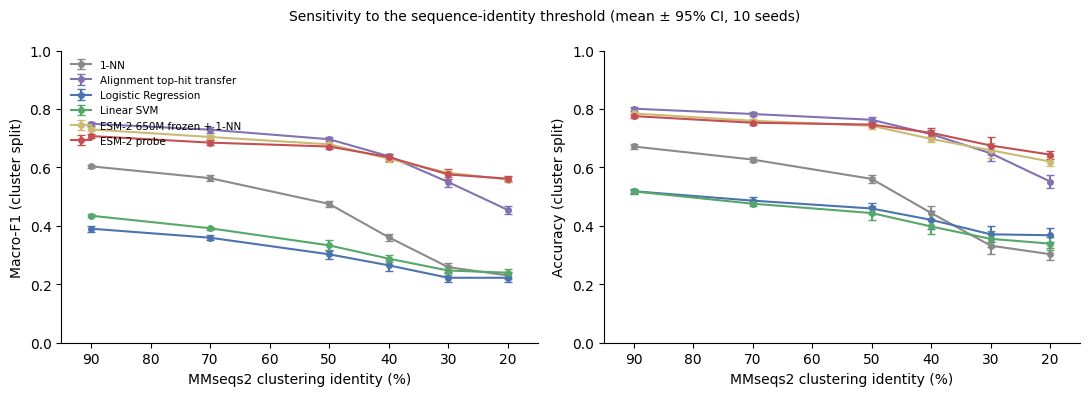

macro-F1 by threshold:

threshold                               0.2    0.3    0.4    0.5    0.7    0.9
model                                                                         
1-NN (memorisation probe)             0.230  0.259  0.361  0.475  0.563  0.604
Alignment top-hit transfer (MMseqs2)  0.455  0.550  0.638  0.696  0.729  0.749
ESM-2 650M frozen + 1-NN              0.559  0.581  0.630  0.679  0.704  0.730
ESM-2 650M frozen + linear probe      0.561  0.576  0.635  0.671  0.685  0.707
Linear SVM                            0.240  0.247  0.288  0.333  0.392  0.435
Logistic Regression                   0.222  0.222  0.265  0.303  0.359  0.390


In [14]:
import matplotlib.pyplot as plt
sw = pd.read_csv(f"{W}/sweep_results.csv")
ORDER = ["1-NN (memorisation probe)", "Alignment top-hit transfer (MMseqs2)",
         "Logistic Regression", "Linear SVM",
         "ESM-2 650M frozen + 1-NN", ESM_NAME]
# only report models that are actually present, so this cell still runs
# before the new Sections 5b-5d have been executed
ORDER = [m for m in ORDER if m in set(sw.model)]
COL = {"1-NN (memorisation probe)":"#8a8a8a", "Logistic Regression":"#4C72B0",
       "Linear SVM":"#55A868", ESM_NAME:"#C44E52",
       "Alignment top-hit transfer (MMseqs2)":"#8172B2",
       "ESM-2 650M frozen + 1-NN":"#CCB974"}
COL = {**{m: "#333333" for m in ORDER}, **COL}   # fallback, never KeyError
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, met, lab in zip(axes, ["macro_f1", "acc"], ["Macro-F1", "Accuracy"]):
    for m in ORDER:
        g = sw[sw.model==m].groupby("threshold")[met].agg(["mean","std","count"]).sort_index()
        thr = g.index.values*100
        half = 1.96*g["std"].values/np.sqrt(g["count"].values)
        label = "ESM-2 probe" if m==ESM_NAME else m.split(" (")[0]
        ax.errorbar(thr, g["mean"].values, yerr=half, marker="o", ms=4, capsize=3, label=label, color=COL[m])
    ax.set_xlabel("MMseqs2 clustering identity (%)"); ax.set_ylabel(f"{lab} (cluster split)")
    ax.set_xlim(95, 15); ax.set_ylim(0, 1); ax.spines[["top","right"]].set_visible(False)
axes[0].legend(fontsize=7.5, frameon=False, loc="upper left")
fig.suptitle("Sensitivity to the sequence-identity threshold (mean ± 95% CI, 10 seeds)", fontsize=10)
plt.tight_layout(); plt.savefig(f"{W}/leakage_threshold_sweep.png", dpi=300, bbox_inches="tight"); plt.show()
print("macro-F1 by threshold:\n")
print(sw.groupby(["model","threshold"]).macro_f1.mean().unstack().round(3).to_string())

## 6d · Pretraining-aware exposure — max identity of each benchmark sequence to UniRef50 (ESM-2 pretraining proxy) — *Drive-checkpointed & resumable*

Searches **every** benchmark sequence against UniRef50 with **DIAMOND** and records its maximum identity, `id_pre` (seed-independent; reused by 6e).

**Path-safety fix.** An earlier version passed the Drive working path — which contains a space (`Colab Notebooks`) — to the shell unquoted, so `wget` mis-parsed it. This cell now (i) touches Drive **only through Python** (`shutil`/`pandas`, which handle spaces), and (ii) `shlex.quote`s every path that does go to the shell. All shell work happens under `/content` (no spaces).

**Resume on disconnect.**
- The DIAMOND database is cached at `{W}/uniref50.dmnd` (`CACHE_DB_ON_DRIVE`); after a restart it is restored to local disk, skipping the ~12 GB download and `makedb`.
- The search runs in **chunks of `CHUNK` sequences**; each chunk's result is written to `{W}/uniref50_chunks/chunk_XXX.csv`, and completed chunks are skipped on restart.
- The one-time DB build (download + `makedb`) writes to fast local `/content`; if the runtime dies *during that initial build* it re-runs, but everything after it (the cached DB and the chunked search) is fully resumable. To make even the download restart-proof, stage a UniRef50 FASTA on Drive once and point `UNIREF50_FASTA` at it.

When all chunks are present they are concatenated into `uniref50_exposure.csv` and the cached DB is removed to reclaim ~20 GB. If the final CSV already exists the cell is a no-op.

*If you see a stray file named `Colab` in your Drive root, it is a leftover from the earlier bug; the cell will point it out. If it happens to be a complete `uniref50.fasta.gz`, you can rename it and set `UNIREF50_FASTA` to skip re-downloading; otherwise delete it to reclaim space.*

In [15]:
# 6d - max identity of each benchmark sequence to UniRef50 (ESM-2 pretraining proxy), via DIAMOND.
# DRIVE-CHECKPOINTED & RESUMABLE. Path-safe: Drive is touched only via Python (handles the space in
# "Colab Notebooks"); every shell path is shlex.quote-d and all shell work stays under /content.
import os, subprocess, shutil, glob, shlex, numpy as np, pandas as pd
q = shlex.quote

# ---- persistent (Drive) paths: accessed ONLY via Python (space-safe) ----
OUT_PRE   = f"{W}/uniref50_exposure.csv"     # FINAL: id -> id_pre (seed-independent)
CHUNK_DIR = f"{W}/uniref50_chunks"           # per-chunk partial results = resume points
DB_DRIVE  = f"{W}/uniref50.dmnd"             # cached DIAMOND DB (skips re-download+makedb on restart)
# ---- ephemeral (local /content) paths: safe for the shell (no spaces) ----
UNIREF_DIR = "/content/uniref50"
GZ_LOCAL   = f"{UNIREF_DIR}/uniref50.fasta.gz"
DB_LOCAL   = f"{UNIREF_DIR}/uniref50.dmnd"
DIAMOND    = "/content/scratch/diamond"
# ---- options ----
DIAMOND_VER         = "2.1.11"
UNIREF50_FASTA      = ""            # local/Drive UniRef FASTA[.gz] to build from (skips the download)
THREADS             = os.cpu_count() or 4
CHUNK               = 4000          # query sequences per checkpoint (smaller = finer resume)
CACHE_DB_ON_DRIVE   = True          # persist the ~20 GB DB to Drive so a restart skips download+makedb
DELETE_DB_WHEN_DONE = True          # reclaim the ~20 GB once uniref50_exposure.csv is finalised
UNIREF50_URLS = [
    "https://ftp.uniprot.org/pub/databases/uniprot/current_release/uniref/uniref50/uniref50.fasta.gz",
    "https://ftp.ebi.ac.uk/pub/databases/uniprot/current_release/uniref/uniref50/uniref50.fasta.gz",
    "https://ftp.uniprot.org/pub/databases/uniprot/uniref/uniref50/uniref50.fasta.gz",
    "https://ftp.ebi.ac.uk/pub/databases/uniprot/uniref/uniref50/uniref50.fasta.gz",
]

def sh(cmd):
    """Run a shell command, stream+capture output, raise with the tail on failure."""
    print(f"$ {cmd}", flush=True)
    p = subprocess.run(cmd, shell=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    out = p.stdout or ""
    tail = "\n".join(out.splitlines()[-30:])
    if tail:
        print(tail, flush=True)
    if p.returncode != 0:
        raise RuntimeError(f"command failed (exit {p.returncode}): {cmd}\n--- last lines ---\n{tail}")
    return out

def free_gb(path="/content"):
    return shutil.disk_usage(path).free / 2**30

def first_live_url(urls):
    for u in urls:
        r = subprocess.run(f"curl -sIL -o /dev/null -w '%{{http_code}}' {q(u)}",
                           shell=True, stdout=subprocess.PIPE, text=True)
        code = ((r.stdout or "").strip().splitlines() or [""])[-1]
        print(f"  probe {code:>3}  {u}", flush=True)
        if code == "200":
            return u
    return None

if os.path.exists(OUT_PRE):
    _pre = pd.read_csv(OUT_PRE)
    print(f"[skip] uniref50_exposure.csv final -> {len(_pre):,} sequences | "
          f"hit-rate={100*_pre.has_hit.mean():.1f}% | median id_pre={_pre.id_pre.median():.3f} | "
          f"frac id_pre<0.30 = {100*(_pre.id_pre<0.30).mean():.1f}%")
else:
    os.makedirs(UNIREF_DIR, exist_ok=True); os.makedirs(SCRATCH, exist_ok=True); os.makedirs(CHUNK_DIR, exist_ok=True)
    print(f"free disk on /content: {free_gb():.0f} GB", flush=True)

    # note any stray file left by the earlier unquoted-path bug
    stray = "/content/drive/MyDrive/Colab"
    if os.path.isfile(stray):
        print(f"note: stray file '{stray}' ({os.path.getsize(stray)/2**30:.1f} GB) left by an earlier "
              f"download bug. If it is a complete uniref50.fasta.gz, rename it and set UNIREF50_FASTA; "
              f"otherwise delete it to reclaim Drive space.", flush=True)

    # ---- DIAMOND binary ----
    if not os.path.exists(DIAMOND):
        print("downloading DIAMOND ...", flush=True)
        sh(f"cd {q(SCRATCH)} && wget -q https://github.com/bbuchfink/diamond/releases/download/"
           f"v{DIAMOND_VER}/diamond-linux64.tar.gz && tar xzf diamond-linux64.tar.gz")
    assert os.path.exists(DIAMOND), "diamond missing after download"

    # ---- ensure a usable LOCAL DIAMOND DB (resume-aware; Drive via Python only) ----
    if os.path.exists(DB_LOCAL):
        print("[db] local DIAMOND DB present")
    elif os.path.exists(DB_DRIVE):
        print(f"[db] restoring cached DB from Drive ({os.path.getsize(DB_DRIVE)/2**30:.0f} GB) -> local ...", flush=True)
        shutil.copyfile(DB_DRIVE, DB_LOCAL)                       # Python copy: space-safe
    else:
        if UNIREF50_FASTA and os.path.exists(UNIREF50_FASTA):
            print(f"[db] building DIAMOND DB from local FASTA: {UNIREF50_FASTA}", flush=True)
            sh(f"{q(DIAMOND)} makedb --in {q(UNIREF50_FASTA)} -d {q(UNIREF_DIR + '/uniref50')} -p {THREADS}")
        else:
            url = first_live_url(UNIREF50_URLS)
            if url is None:
                raise RuntimeError("no UniRef50 mirror responded 200. Set UNIREF50_FASTA to a local copy, "
                                   "or edit UNIREF50_URLS with a working mirror.")
            print(f"[db] downloading UniRef50 to local /content (resumable within session):\n  {url}", flush=True)
            sh(f"wget -c -O {q(GZ_LOCAL)} {q(url)}")              # local target; no spaces
            print("[db] building DIAMOND DB (reads .gz directly) ...", flush=True)
            sh(f"{q(DIAMOND)} makedb --in {q(GZ_LOCAL)} -d {q(UNIREF_DIR + '/uniref50')} -p {THREADS}")
            os.remove(GZ_LOCAL); print("removed local .gz", flush=True)
        if CACHE_DB_ON_DRIVE:
            print("[db] caching DB to Drive for restart-resume ...", flush=True)
            shutil.copyfile(DB_LOCAL, DB_DRIVE)                  # Python copy: space-safe

    # ---- query set (dedup identical sequences: id_pre depends only on the sequence) ----
    d = pd.read_csv(f"{W}/dataset_clustered.csv")
    ids, seqs = d.id.values, d.sequence.values
    n = len(ids)
    uniq = {}
    for s in seqs:
        if s not in uniq:
            uniq[s] = len(uniq)
    useqs = [None] * len(uniq)
    for s, i in uniq.items():
        useqs[i] = s
    uidx_of_id = np.array([uniq[s] for s in seqs])          # each id -> its unique-sequence row
    U = len(useqs)
    print(f"query sequences: {n:,}  ->  {U:,} unique  "
          f"({100*(1-U/max(n,1)):.1f}% exact duplicates skipped)", flush=True)

    # Two-pass (tiered-sensitivity) search. We only need the MAX identity to UniRef50, and only the
    # 0.30 cutoff feeds Section 6e. A --fast pass reliably finds every hit at >=~40% identity (high
    # identity is trivial to seed), so any sequence it scores >= MARGIN is finalised; only the residual
    # (no/low fast hit) is re-run with --very-sensitive. Because MARGIN (0.40) sits safely above the
    # 0.30 cutoff, the pre<30 / pre>=30 classification is IDENTICAL to running --very-sensitive on
    # everything -- at a fraction of the cost, since most PDB sequences have a near-identical UniRef50
    # match found instantly by the fast pass.
    MARGIN     = 0.40
    FAST_FLAGS = "--fast"              # if your DIAMOND build rejects this flag, use "" (default = fast)
    SENS_FLAGS = "--very-sensitive"    # unchanged: the twilight-zone mode, now only on the residual
    FAST_DIR   = f"{W}/uniref50_chunks_fast"     # phase-A checkpoints (resume points)
    SENS_DIR   = f"{W}/uniref50_chunks_sens"     # phase-B checkpoints (resume points)
    os.makedirs(FAST_DIR, exist_ok=True); os.makedirs(SENS_DIR, exist_ok=True)

    def diamond_maxid(u_indices, tag, flags, kmax, out_dir):
        """DIAMOND blastp for the given unique-seq indices; checkpoint {u -> max identity} to out_dir."""
        u_indices = list(u_indices)
        ck = f"{out_dir}/{tag}.csv"
        if os.path.exists(ck):
            r = pd.read_csv(ck); return dict(zip(r.u, r.idp))     # resume: already computed
        qfa = f"{UNIREF_DIR}/q_{tag}.fasta"; tsv = f"{UNIREF_DIR}/h_{tag}.tsv"
        with open(qfa, "w") as f:
            for u in u_indices:
                f.write(f">{u}\n{useqs[u]}\n")                  # FASTA header = unique-seq index
        sh(f"{q(DIAMOND)} blastp -d {q(UNIREF_DIR + '/uniref50')} -q {q(qfa)} -o {q(tsv)} "
           f"--outfmt 6 qseqid pident -k {kmax} {flags} -e 1e-3 -p {THREADS} --quiet")
        best = {}
        if os.path.exists(tsv) and os.path.getsize(tsv) > 0:
            h = pd.read_csv(tsv, sep="\t", header=None, names=["u", "pident"])
            best = (h.groupby("u").pident.max() / 100.0).to_dict()
        for f in (qfa, tsv):
            if os.path.exists(f): os.remove(f)
        pd.DataFrame({"u": u_indices, "idp": [best.get(u, 0.0) for u in u_indices]}).to_csv(ck, index=False)
        return {u: best.get(u, 0.0) for u in u_indices}

    # ---- Phase A: fast pass over ALL unique sequences, in resumable chunks ----
    idp_fast = {}
    nA = (U + CHUNK - 1) // CHUNK
    for k in range(nA):
        lo, hi = k*CHUNK, min((k+1)*CHUNK, U)
        print(f"[fast {k+1}/{nA}] unique seqs {lo:,}-{hi:,}", flush=True)
        idp_fast.update(diamond_maxid(range(lo, hi), f"fast_{k:03d}", FAST_FLAGS, 5, FAST_DIR))

    # ---- Phase B: --very-sensitive ONLY on the residual (fast identity < MARGIN) ----
    residual = [u for u in range(U) if idp_fast.get(u, 0.0) < MARGIN]
    print(f"residual needing --very-sensitive: {len(residual):,} / {U:,} unique "
          f"({100*len(residual)/max(U,1):.1f}%)  [the rest are finalised by the fast pass]", flush=True)
    idp_sens = {}
    nB = (len(residual) + CHUNK - 1) // CHUNK
    for k in range(nB):
        lo, hi = k*CHUNK, min((k+1)*CHUNK, len(residual))
        print(f"[sens {k+1}/{nB}] residual seqs {lo:,}-{hi:,}", flush=True)
        idp_sens.update(diamond_maxid(residual[lo:hi], f"sens_{k:03d}", SENS_FLAGS, 25, SENS_DIR))

    # ---- finalise: per unique seq, id_pre = max(fast, sensitive); then expand to every id ----
    idp_u = np.array([max(idp_fast.get(u, 0.0), idp_sens.get(u, 0.0)) for u in range(U)])
    id_pre_all = idp_u[uidx_of_id].astype(float)
    pre = pd.DataFrame({"id": ids, "id_pre": id_pre_all, "has_hit": (id_pre_all > 0.0).astype(int)})
    pre.to_csv(OUT_PRE, index=False)
    print(f"\nwrote {OUT_PRE}: {len(pre):,} sequences")
    print(f"  hit-rate against UniRef50  : {100*pre.has_hit.mean():.1f}%")
    print(f"  median id_pre              : {pre.id_pre.median():.3f}")
    print(f"  fraction with id_pre>=0.30 : {100*(pre.id_pre>=0.30).mean():.1f}%")
    print(f"  fraction with id_pre<0.30  : {100*(pre.id_pre<0.30).mean():.1f}%   <- candidate 'novel to pretraining'")

    if DELETE_DB_WHEN_DONE and os.path.exists(DB_DRIVE):
        os.remove(DB_DRIVE); print("reclaimed Drive space: removed cached uniref50.dmnd", flush=True)


free disk on /content: 87 GB
note: stray file '/content/drive/MyDrive/Colab' (4.9 GB) left by an earlier download bug. If it is a complete uniref50.fasta.gz, rename it and set UNIREF50_FASTA; otherwise delete it to reclaim Drive space.
downloading DIAMOND ...
$ cd /content/scratch && wget -q https://github.com/bbuchfink/diamond/releases/download/v2.1.11/diamond-linux64.tar.gz && tar xzf diamond-linux64.tar.gz
[db] restoring cached DB from Drive (16 GB) -> local ...
query sequences: 40,211  ->  40,211 unique  (0.0% exact duplicates skipped)
[fast 1/11] unique seqs 0-4,000
$ /content/scratch/diamond blastp -d /content/uniref50/uniref50 -q /content/uniref50/q_fast_000.fasta -o /content/uniref50/h_fast_000.tsv --outfmt 6 qseqid pident -k 5 --fast -e 1e-3 -p 2 --quiet
[fast 2/11] unique seqs 4,000-8,000
$ /content/scratch/diamond blastp -d /content/uniref50/uniref50 -q /content/uniref50/q_fast_001.fasta -o /content/uniref50/h_fast_001.tsv --outfmt 6 qseqid pident -k 5 --fast -e 1e-3 -p 2 --

## 6e · Two-way exposure stratification — training-set identity × pretraining-proxy identity — *Drive-checkpointed & resumable*

Cross-classifies every cluster-split test sequence at a 30% cut on `id_train` (per seed) and `id_pre` (Section 6d), giving four strata, and records per-model accuracy for the four Table 7 models.

**Resume on disconnect.** Each seed is computed independently and its rows are written to `{W}/pretraining_strat_chunks/seed_S.csv`. On a restart, seeds whose checkpoint already exists are skipped and the run continues with the remaining seeds. Once all ten seed files are present they are concatenated into `pretraining_stratified_results.csv`, and the summary (`pretraining_stratified_summary.csv`) and Figure 5 are built. If the final results file already exists the cell is a no-op.

The primary cell is **distant / distant** (`id_train < 30%` and `id_pre < 30%`): a surviving ESM-2 margin there is evidence of generalisation beyond pretraining exposure. Stratum sizes are reported first; do not interpret a stratum whose per-seed count is too small. These outputs fill Table 7 and Figure 5 of the revised manuscript.

seed=0 checkpoint  tr<30/pr<30:0  tr<30/pr>=30:4467  tr>=30/pr<30:0  tr>=30/pr>=30:5914
seed=1 checkpoint  tr<30/pr<30:0  tr<30/pr>=30:4082  tr>=30/pr<30:0  tr>=30/pr>=30:3101
seed=2 checkpoint  tr<30/pr<30:2  tr<30/pr>=30:3728  tr>=30/pr<30:0  tr>=30/pr>=30:3414
seed=3 checkpoint  tr<30/pr<30:4  tr<30/pr>=30:4184  tr>=30/pr<30:0  tr>=30/pr>=30:3977
seed=4 checkpoint  tr<30/pr<30:3  tr<30/pr>=30:4133  tr>=30/pr<30:0  tr>=30/pr>=30:4220
seed=5 checkpoint  tr<30/pr<30:5  tr<30/pr>=30:4348  tr>=30/pr<30:0  tr>=30/pr>=30:3327
seed=6 checkpoint  tr<30/pr<30:0  tr<30/pr>=30:4113  tr>=30/pr<30:0  tr>=30/pr>=30:3007
seed=7 checkpoint  tr<30/pr<30:1  tr<30/pr>=30:4027  tr>=30/pr<30:0  tr>=30/pr>=30:5991
seed=8 checkpoint  tr<30/pr<30:4  tr<30/pr>=30:4295  tr>=30/pr<30:1  tr>=30/pr>=30:5640
seed=9 checkpoint  tr<30/pr<30:1  tr<30/pr>=30:4160  tr>=30/pr<30:0  tr>=30/pr>=30:3858

Mean accuracy by exposure stratum (cluster split):

model                    1-NN (memorisation probe)  Alignment top-h

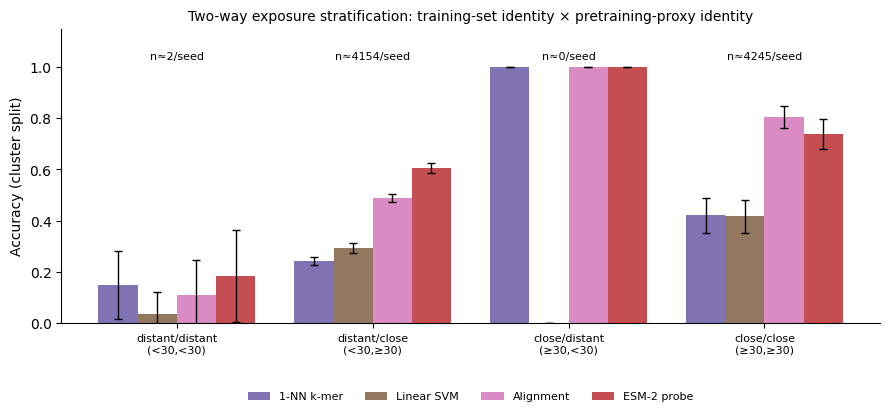


saved -> /content/drive/MyDrive/Colab Notebooks/pdb_data/work/pretraining_stratified_results.csv
         /content/drive/MyDrive/Colab Notebooks/pdb_data/work/pretraining_stratified_summary.csv
         /content/drive/MyDrive/Colab Notebooks/pdb_data/work/pretraining_stratified_figure.png


In [16]:
# 6e - two-way exposure stratification: id_train (per seed) x id_pre (Section 6d).
# DRIVE-CHECKPOINTED & RESUMABLE: each seed's rows are written to Drive; a restart skips
# completed seeds and continues. The final table/figure are built once all seeds are present.
import os, subprocess, glob, numpy as np, pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn import config_context
from collections import Counter
import warnings; warnings.filterwarnings("ignore")

OUT      = f"{W}/pretraining_stratified_results.csv"
SUMM     = f"{W}/pretraining_stratified_summary.csv"
FIG      = f"{W}/pretraining_stratified_figure.png"
SEED_DIR = f"{W}/pretraining_strat_chunks"    # per-seed checkpoints = resume points
SEEDS    = list(range(10))
MM       = "/content/scratch/mmseqs/bin/mmseqs"
CUT      = 0.30
MODELS = ["1-NN (memorisation probe)", "Linear SVM",
          "Alignment top-hit transfer (MMseqs2)", "ESM-2 650M frozen + linear probe"]

if os.path.exists(OUT):
    print(f"[skip] {OUT} already final")
else:
    assert os.path.exists(f"{W}/uniref50_exposure.csv"), "run Section 6d first"
    os.makedirs(SEED_DIR, exist_ok=True); os.makedirs(SCRATCH, exist_ok=True)
    if not os.path.exists(MM):
        subprocess.run(f"cd {SCRATCH} && wget -q https://mmseqs.com/latest/mmseqs-linux-avx2.tar.gz "
                       f"&& tar xzf mmseqs-linux-avx2.tar.gz", shell=True, check=True)

    d  = pd.read_csv(f"{W}/dataset_clustered.csv")
    X  = np.load(f"{W}/esm2_embeddings.npy").astype(np.float32)
    y  = d.classification.values
    ids, seqs = d.id.values, d.sequence.values
    idx = np.arange(len(d)); groups = d.cluster.values
    kmers = np.array([" ".join(s[i:i+3] for i in range(len(s)-2)) for s in seqs])
    _pre = pd.read_csv(f"{W}/uniref50_exposure.csv")
    id_pre_map = dict(zip(_pre.id, _pre.id_pre))
    id2lab = dict(zip(ids, y))

    def align_train(tr, te, tag):
        """One MMseqs2 search (test vs train) -> (max identity per test seq, top-hit-transfer label).
        Replaces the two former per-seed searches (which shared query, target, and sensitivity) with a
        single search, halving the alignment work per seed. --max-seqs 50 (>= the former 20 used for the
        identity search) can only find equal-or-more hits, so the id_train <30/>=30 split is unchanged-
        to-more-complete; the top-hit label (argmax bits) is identical to before."""
        qf, tf, out = f"{SCRATCH}/q_{tag}.fasta", f"{SCRATCH}/t_{tag}.fasta", f"{SCRATCH}/aln_{tag}.m8"
        with open(qf,"w") as f:
            for j in te: f.write(f">{ids[j]}\n{seqs[j]}\n")
        with open(tf,"w") as f:
            for j in tr: f.write(f">{ids[j]}\n{seqs[j]}\n")
        subprocess.run(f"{MM} easy-search {qf} {tf} {out} {SCRATCH}/tmp_{tag} "
                       f"--min-seq-id 0 -c 0.0 -s 5.7 --max-seqs 50 "
                       f"--format-output query,target,fident,bits -v 1", shell=True, check=True)
        idmax, tophit = {}, {}
        if os.path.exists(out) and os.path.getsize(out) > 0:
            h = pd.read_csv(out, sep="\t", header=None, names=["query","target","fident","bits"])
            idmax  = h.groupby("query").fident.max().to_dict()
            hb = h.sort_values("bits", ascending=False).drop_duplicates("query")
            tophit = dict(zip(hb["query"], hb["target"]))
        maj = Counter(y[tr]).most_common(1)[0][0]
        for f in (qf, tf, out):
            if os.path.exists(f): os.remove(f)
        id_tr = np.array([idmax.get(ids[j], 0.0) for j in te], dtype=float)
        lab   = np.array([id2lab[tophit[ids[j]]] if ids[j] in tophit else maj for j in te], dtype=object)
        return id_tr, lab

    # ---- per-seed compute with a Drive checkpoint after each seed ----
    for seed in SEEDS:
        sf = f"{SEED_DIR}/seed_{seed}.csv"
        if os.path.exists(sf):
            print(f"[skip] seed {seed} checkpoint present", flush=True)
            continue
        tr, te = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
                      .split(idx, y, groups=groups))
        id_tr, top_lab = align_train(tr, te, f"{seed}")
        id_pre = np.array([id_pre_map.get(ids[j], 0.0) for j in te], dtype=float)

        preds = {}
        vec = TfidfVectorizer(analyzer="word", token_pattern=r"\S+", min_df=3, sublinear_tf=True)
        Xtr, Xte = vec.fit_transform(kmers[tr]), vec.transform(kmers[te])
        with config_context(working_memory=256):
            preds["1-NN (memorisation probe)"] = KNeighborsClassifier(
                n_neighbors=1, metric="cosine", algorithm="brute").fit(Xtr, y[tr]).predict(Xte)
            preds["Linear SVM"] = LinearSVC(C=0.5, max_iter=3000).fit(Xtr, y[tr]).predict(Xte)
        del Xtr, Xte, vec
        sc = StandardScaler().fit(X[tr])
        preds["ESM-2 650M frozen + linear probe"] = LogisticRegression(max_iter=3000).fit(
            sc.transform(X[tr]).astype(np.float32), y[tr]).predict(sc.transform(X[te]).astype(np.float32))
        preds["Alignment top-hit transfer (MMseqs2)"] = top_lab

        s_tr  = np.where(id_tr  < CUT, "train<30", "train>=30")
        s_pre = np.where(id_pre < CUT, "pre<30",  "pre>=30")
        rows = []
        for a in ["train<30","train>=30"]:
            for b in ["pre<30","pre>=30"]:
                m = (s_tr==a) & (s_pre==b); nn = int(m.sum())
                for model in MODELS:
                    acc = float((np.asarray(preds[model])[m]==y[te][m]).mean()) if nn>0 else np.nan
                    rows.append(dict(seed=seed, id_train_bin=a, id_pre_bin=b,
                                     model=model, n=nn, accuracy=acc))
        pd.DataFrame(rows).to_csv(sf, index=False)     # <-- checkpoint this seed on Drive
        counts = {(a, b): int(((s_tr == a) & (s_pre == b)).sum())
                  for a in ['train<30', 'train>=30'] for b in ['pre<30', 'pre>=30']}
        tag = {'train<30': 'tr<30', 'train>=30': 'tr>=30', 'pre<30': 'pr<30', 'pre>=30': 'pr>=30'}
        print(f"seed={seed} checkpoint  " + "  ".join(
            f"{tag[a]}/{tag[b]}:{counts[(a, b)]}"
            for a in ['train<30', 'train>=30'] for b in ['pre<30', 'pre>=30']), flush=True)

    # ---- all seeds present: assemble final results, summary, and Figure 5 ----
    res = pd.concat([pd.read_csv(f"{SEED_DIR}/seed_{s}.csv") for s in SEEDS], ignore_index=True)
    res.to_csv(OUT, index=False)

    summ = (res.groupby(["id_train_bin","id_pre_bin","model"])
               .agg(n_mean=("n","mean"), acc_mean=("accuracy","mean"), acc_sd=("accuracy","std"))
               .reset_index())
    summ.to_csv(SUMM, index=False)

    piv = summ.pivot_table(index=["id_train_bin","id_pre_bin"], columns="model", values="acc_mean")
    print("\nMean accuracy by exposure stratum (cluster split):\n")
    print(piv.round(3).to_string())
    print("\nMean test sequences per stratum:")
    print(summ.groupby(["id_train_bin","id_pre_bin"]).n_mean.first().round(0).to_string())
    print("\n-> primary cell = (train<30, pre<30), the doubly-distant stratum.")
    print("   A retained ESM-2 margin there is evidence of generalisation beyond pretraining exposure;")
    print("   its absence localises the advantage to pretraining exposure. Fills Table 7 / Figure 5.")

    # ---- Figure 5 ----
    import matplotlib.pyplot as plt
    order_strata = [("train<30","pre<30"), ("train<30","pre>=30"),
                    ("train>=30","pre<30"), ("train>=30","pre>=30")]
    labels = ["distant/distant\n(<30,<30)", "distant/close\n(<30,\u226530)",
              "close/distant\n(\u226530,<30)", "close/close\n(\u226530,\u226530)"]
    short  = {"1-NN (memorisation probe)":"1-NN k-mer", "Linear SVM":"Linear SVM",
              "Alignment top-hit transfer (MMseqs2)":"Alignment", "ESM-2 650M frozen + linear probe":"ESM-2 probe"}
    colors = {"1-NN k-mer":"#8172B3","Linear SVM":"#937860","Alignment":"#DA8BC3","ESM-2 probe":"#C44E52"}
    fig, ax = plt.subplots(figsize=(9,4.4)); x = np.arange(len(order_strata)); w = 0.2
    for k, model in enumerate(MODELS):
        means, sds = [], []
        for a,b in order_strata:
            sub = res[(res.id_train_bin==a)&(res.id_pre_bin==b)&(res.model==model)]
            means.append(np.nanmean(sub.accuracy)); sds.append(np.nanstd(sub.accuracy))
        lab = short[model]
        ax.bar(x + (k-1.5)*w, means, w, yerr=sds, capsize=3, label=lab, color=colors[lab], error_kw=dict(lw=1))
    for i,(a,b) in enumerate(order_strata):
        nseq = res[(res.id_train_bin==a)&(res.id_pre_bin==b)&(res.model==MODELS[0])].n.mean()
        ax.text(i, 1.03, f"n\u2248{nseq:.0f}/seed", ha="center", fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel("Accuracy (cluster split)"); ax.set_ylim(0, 1.15)
    ax.legend(ncol=4, frameon=False, fontsize=8, loc="lower center", bbox_to_anchor=(0.5, -0.30))
    ax.spines[["top","right"]].set_visible(False)
    ax.set_title("Two-way exposure stratification: training-set identity \u00d7 pretraining-proxy identity", fontsize=10)
    plt.tight_layout(); plt.savefig(FIG, dpi=300, bbox_inches="tight"); plt.show()
    print(f"\nsaved -> {OUT}\n         {SUMM}\n         {FIG}")


## 7 · Aggregate — mean ± s.d. and 95% CI

In [17]:
res = pd.read_csv(f"{W}/results_10seed.csv")
ORDER = ["1-NN (memorisation probe)", "Alignment top-hit transfer (MMseqs2)",
         "Logistic Regression", "Linear SVM",
         "ESM-2 650M frozen + 1-NN", ESM_NAME]
# only report models that are actually present, so this cell still runs
# before the new Sections 5b-5d have been executed
ORDER = [m for m in ORDER if m in set(res.model)]
agg = (res.groupby(["model", "split"])
          .agg(acc_mean=("acc","mean"), acc_std=("acc","std"),
               f1_mean=("macro_f1","mean"), f1_std=("macro_f1","std"))
          .round(4).reset_index())
agg.to_csv(f"{W}/results_10seed_summary.csv", index=False)
n_seeds = res.seed.nunique()

print(f"Macro-F1  (mean ± s.d. over {n_seeds} seeds)\n")
for m in ORDER:
    r_ = agg[(agg.model==m) & (agg.split=="random")].iloc[0]
    c_ = agg[(agg.model==m) & (agg.split=="cluster")].iloc[0]
    drop = 100 * (c_.f1_mean - r_.f1_mean) / r_.f1_mean
    print(f"  {m:34s} random {r_.f1_mean:.3f}±{r_.f1_std:.3f}   cluster {c_.f1_mean:.3f}±{c_.f1_std:.3f}   ({drop:+.0f}%)")

print(f"\nAccuracy  (mean ± s.d. over {n_seeds} seeds)\n")
for m in ORDER:
    r_ = agg[(agg.model==m) & (agg.split=="random")].iloc[0]
    c_ = agg[(agg.model==m) & (agg.split=="cluster")].iloc[0]
    drop = 100 * (c_.acc_mean - r_.acc_mean) / r_.acc_mean
    print(f"  {m:34s} random {r_.acc_mean:.3f}±{r_.acc_std:.3f}   cluster {c_.acc_mean:.3f}±{c_.acc_std:.3f}   ({drop:+.0f}%)")

# --- 95% confidence intervals on the identity-controlled cluster split (both metrics) ---
import numpy as np
from scipy import stats
def ci95(x):
    x = np.asarray(x); m = x.mean()
    half = stats.t.ppf(0.975, len(x)-1) * x.std(ddof=1) / (len(x) ** 0.5)
    return m, m - half, m + half

ci_rows = []
for metric, col in [("macro_f1", "macro_f1"), ("accuracy", "acc")]:
    for m in ORDER:
        mean, lo, hi = ci95(res[(res.model==m) & (res.split=="cluster")][col].values)
        ci_rows.append(dict(model=m, metric=metric, split="cluster",
                            mean=round(mean,4), ci_low=round(lo,4), ci_high=round(hi,4)))
ci_df = pd.DataFrame(ci_rows)
ci_df.to_csv(f"{W}/results_10seed_ci.csv", index=False)

print(f"\n95% CI for cluster-split Macro-F1 (t-based, {n_seeds} seeds)\n")
for m in ORDER:
    r_ = ci_df[(ci_df.model==m) & (ci_df.metric=="macro_f1")].iloc[0]
    print(f"  {m:34s} {r_['mean']:.3f}  [{r_['ci_low']:.3f}, {r_['ci_high']:.3f}]")

print(f"\n95% CI for cluster-split Accuracy (t-based, {n_seeds} seeds)\n")
for m in ORDER:
    r_ = ci_df[(ci_df.model==m) & (ci_df.metric=="accuracy")].iloc[0]
    print(f"  {m:34s} {r_['mean']:.3f}  [{r_['ci_low']:.3f}, {r_['ci_high']:.3f}]")

Macro-F1  (mean ± s.d. over 10 seeds)

  1-NN (memorisation probe)          random 0.770±0.006   cluster 0.259±0.024   (-66%)
  Alignment top-hit transfer (MMseqs2) random 0.843±0.005   cluster 0.549±0.028   (-35%)
  Logistic Regression                random 0.602±0.007   cluster 0.222±0.024   (-63%)
  Linear SVM                         random 0.666±0.007   cluster 0.247±0.023   (-63%)
  ESM-2 650M frozen + 1-NN           random 0.827±0.005   cluster 0.582±0.012   (-30%)
  ESM-2 650M frozen + linear probe   random 0.797±0.007   cluster 0.576±0.028   (-28%)

Accuracy  (mean ± s.d. over 10 seeds)

  1-NN (memorisation probe)          random 0.811±0.004   cluster 0.332±0.044   (-59%)
  Alignment top-hit transfer (MMseqs2) random 0.872±0.004   cluster 0.648±0.042   (-26%)
  Logistic Regression                random 0.667±0.006   cluster 0.371±0.044   (-44%)
  Linear SVM                         random 0.706±0.005   cluster 0.355±0.046   (-50%)
  ESM-2 650M frozen + 1-NN           random 0.8

## 8 · Figures — comparison bars (mean ± s.d.) and cluster-split 95% CI

plotting 6 models: ['1-NN (memorisation probe)', 'Alignment top-hit transfer (MMseqs2)', 'Logistic Regression', 'Linear SVM', 'ESM-2 650M frozen + 1-NN', 'ESM-2 650M frozen + linear probe']


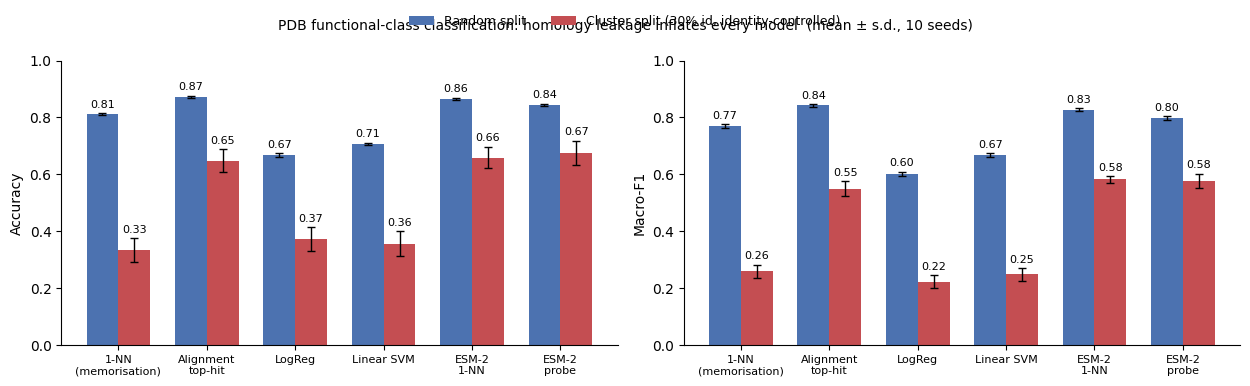

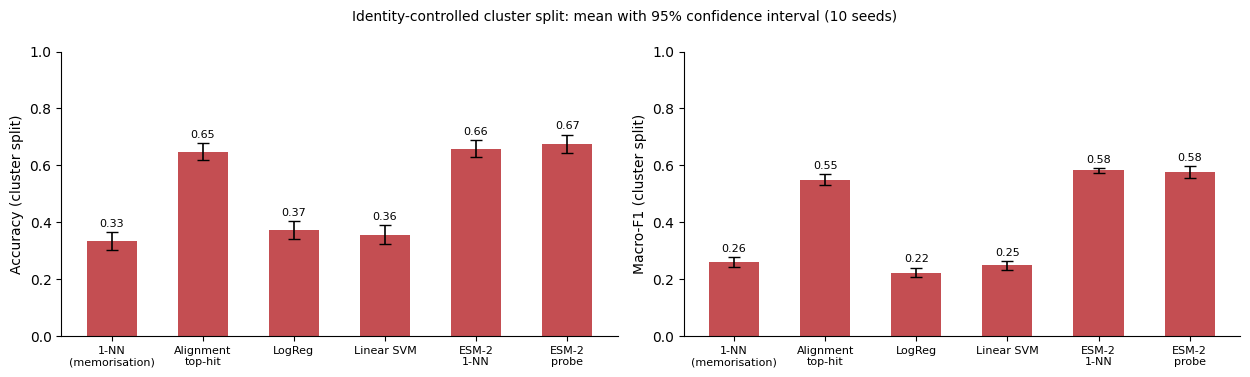

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
res = pd.read_csv(f"{W}/results_10seed.csv")
# Self-contained model list: do not depend on ORDER surviving from an earlier cell,
# and keep it to models present under BOTH splits so the paired bars are well defined.
_CANON = ["1-NN (memorisation probe)", "Alignment top-hit transfer (MMseqs2)",
          "Logistic Regression", "Linear SVM",
          "ESM-2 650M frozen + 1-NN", ESM_NAME]
_both = (set(res[res.split == "random"].model) & set(res[res.split == "cluster"].model))
ORDER = [m for m in _CANON if m in _both]

# Labels are DERIVED from ORDER, so len(LABELS) == len(ORDER) by construction.
# (A hardcoded list silently desynchronises whenever a model is added.)
_SHORT = {
    "1-NN (memorisation probe)":            "1-NN\n(memorisation)",
    "Alignment top-hit transfer (MMseqs2)": "Alignment\ntop-hit",
    "Logistic Regression":                  "LogReg",
    "Linear SVM":                           "Linear SVM",
    "ESM-2 650M frozen + 1-NN":             "ESM-2\n1-NN",
    ESM_NAME:                               "ESM-2\nprobe",
}
LABELS = [_SHORT.get(m, m.split(" (")[0]) for m in ORDER]
assert len(LABELS) == len(ORDER), "labels/ORDER desynchronised"
print(f"plotting {len(ORDER)} models: {ORDER}")

def ms(m, sp, met):
    v = res[(res.model==m) & (res.split==sp)][met].values
    return v.mean(), v.std()

# --- Figure 1: random vs cluster, mean ± s.d. ---
fig, axes = plt.subplots(1, 2, figsize=(max(11, 2.1*len(ORDER)), 3.8))
for ax, met, lab in zip(axes, ["acc", "macro_f1"], ["Accuracy", "Macro-F1"]):
    rm, rs = zip(*[ms(m, "random",  met) for m in ORDER])
    cm, cs = zip(*[ms(m, "cluster", met) for m in ORDER])
    x, w = np.arange(len(ORDER)), 0.36
    ax.bar(x - w/2, rm, w, yerr=rs, capsize=3, label="Random split", color="#4C72B0", error_kw=dict(lw=1))
    ax.bar(x + w/2, cm, w, yerr=cs, capsize=3, label="Cluster split (30% id, identity-controlled)", color="#C44E52", error_kw=dict(lw=1))
    for i, (v, s) in enumerate(zip(rm, rs)): ax.text(i - w/2, v + s + .02, f"{v:.2f}", ha="center", fontsize=8)
    for i, (v, s) in enumerate(zip(cm, cs)): ax.text(i + w/2, v + s + .02, f"{v:.2f}", ha="center", fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(LABELS, fontsize=8)
    ax.set_ylabel(lab); ax.set_ylim(0, 1.0); ax.spines[["top", "right"]].set_visible(False)
fig.legend(labels=["Random split","Cluster split (30% id, identity-controlled)"], loc="upper center", ncol=2, frameon=False, fontsize=9, bbox_to_anchor=(0.5, 1.02))
fig.suptitle(f"PDB functional-class classification: homology leakage inflates every model  (mean ± s.d., {res.seed.nunique()} seeds)", fontsize=10)
plt.tight_layout(); plt.savefig(f"{W}/leakage_figure_10seed.png", dpi=300, bbox_inches="tight")
plt.show()

# --- Figure 2: identity-controlled cluster split, mean with 95% CI (Accuracy and Macro-F1) ---
def ci_half(x):
    x = np.asarray(x)
    return x.mean(), stats.t.ppf(0.975, len(x)-1) * x.std(ddof=1) / (len(x) ** 0.5)

fig2, axes2 = plt.subplots(1, 2, figsize=(max(11, 2.1*len(ORDER)), 3.8))
for ax, met, lab in zip(axes2, ["acc", "macro_f1"], ["Accuracy", "Macro-F1"]):
    means, halves = zip(*[ci_half(res[(res.model==m) & (res.split=="cluster")][met].values) for m in ORDER])
    x = np.arange(len(ORDER))
    ax.bar(x, means, 0.55, yerr=halves, capsize=4, color="#C44E52", error_kw=dict(lw=1.2))
    for i, (mn, h) in enumerate(zip(means, halves)):
        ax.text(i, mn + h + .02, f"{mn:.2f}", ha="center", fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(LABELS, fontsize=8)
    ax.set_ylabel(f"{lab} (cluster split)"); ax.set_ylim(0, 1.0); ax.spines[["top", "right"]].set_visible(False)
fig2.suptitle(f"Identity-controlled cluster split: mean with 95% confidence interval ({res.seed.nunique()} seeds)", fontsize=10)
plt.tight_layout(); plt.savefig(f"{W}/leakage_ci_cluster.png", dpi=300, bbox_inches="tight")
plt.show()

## 9 · Paired tests — ESM-2 vs all baselines (95% CI and effect size)

Reproduces the manuscript's paired comparison table on the identity-controlled split, with 95% confidence intervals, paired $t$/Wilcoxon $p$-values, and paired Cohen $d_z$ effect sizes.

In [19]:
import numpy as np
from scipy import stats
res = pd.read_csv(f"{W}/results_10seed.csv")
n = res.seed.nunique()
BASELINES = ["Logistic Regression", "Linear SVM", "1-NN (memorisation probe)",
             "Alignment top-hit transfer (MMseqs2)", "ESM-2 650M frozen + 1-NN"]
# restrict to whatever has been run so far
_present = set(res[res.split == "cluster"].model)
BASELINES = [b for b in BASELINES if b in _present]

def paired_table(metric):
    piv = res[res.split=="cluster"].pivot(index="seed", columns="model", values=metric)
    esm = piv[ESM_NAME].values
    rows = []
    for base in BASELINES:
        b = piv[base].values
        diff = esm - b
        m, sd = diff.mean(), diff.std(ddof=1)
        half = stats.t.ppf(0.975, n-1) * sd / (n ** 0.5)
        t, p = stats.ttest_rel(esm, b)
        dz = m / sd
        w = stats.wilcoxon(esm, b)
        rows.append(dict(metric=metric, baseline=base, gap=round(m,4), gap_sd=round(sd,4),
                         ci_low=round(m-half,4), ci_high=round(m+half,4),
                         t=round(t,2), p=p, cohen_dz=round(dz,2), wilcoxon_p=round(w.pvalue,4)))
    return pd.DataFrame(rows)

tables = []
for metric, name in [("macro_f1", "Macro-F1"), ("acc", "Accuracy")]:
    tbl = paired_table(metric)
    tables.append(tbl)
    print(f"ESM-2 vs baselines on the identity-controlled cluster split ({name}, paired, n={n})\n")
    print(f"  {'baseline':26s} {'gap ± sd':>14s} {'95% CI':>18s} {'t':>7s} {'p':>10s} {'d_z':>6s} {'Wilcoxon':>9s}")
    for _, r in tbl.iterrows():
        print(f"  {r['baseline']:26s} {r['gap']:.3f} ± {r['gap_sd']:.3f}  [{r['ci_low']:.3f}, {r['ci_high']:.3f}]  {r['t']:6.1f} {r['p']:10.2e} {r['cohen_dz']:6.1f} {r['wilcoxon_p']:9.4f}")
    print()

paired_df = pd.concat(tables, ignore_index=True)
paired_df.to_csv(f"{W}/results_10seed_paired.csv", index=False)
print("saved -> results_10seed_paired.csv")

ESM-2 vs baselines on the identity-controlled cluster split (Macro-F1, paired, n=10)

  baseline                         gap ± sd             95% CI       t          p    d_z  Wilcoxon
  Logistic Regression        0.354 ± 0.019  [0.340, 0.367]    57.5   7.30e-13   18.2    0.0020
  Linear SVM                 0.329 ± 0.025  [0.311, 0.347]    41.2   1.44e-11   13.1    0.0020
  1-NN (memorisation probe)  0.317 ± 0.030  [0.296, 0.339]    33.8   8.65e-11   10.7    0.0020
  Alignment top-hit transfer (MMseqs2) 0.027 ± 0.030  [0.005, 0.049]     2.8   2.07e-02    0.9    0.0371
  ESM-2 650M frozen + 1-NN   -0.006 ± 0.023  [-0.022, 0.011]    -0.8   4.64e-01   -0.2    0.6250

ESM-2 vs baselines on the identity-controlled cluster split (Accuracy, paired, n=10)

  baseline                         gap ± sd             95% CI       t          p    d_z  Wilcoxon
  Logistic Regression        0.304 ± 0.040  [0.276, 0.332]    24.3   1.61e-09    7.7    0.0020
  Linear SVM                 0.320 ± 0.037  [0.

## 10 · Save all result outputs and bundle

In [20]:
import shutil
# every persisted result output from this study
arts = [
    "dataset_clustered.csv",         # curated dataset + 30% identity clusters
    "results_10seed.csv",            # per-seed raw metrics (accuracy + macro-F1)
    "results_10seed_summary.csv",    # mean/std per model and split
    "results_10seed_ci.csv",         # 95% CI, cluster split (accuracy + macro-F1)
    "results_10seed_paired.csv",     # paired ESM-2 vs baselines (accuracy + macro-F1)
    "leakage_exposure.csv",          # model-free leakage exposure
    "leakage_figure_10seed.png",     # random vs cluster bars (accuracy + macro-F1)
    "leakage_ci_cluster.png",
    "sweep_results.csv",
    "filtering_flow.csv",              # exact filtering counts (Major 6)
    "class_support_by_seed.csv",       # cluster-split class balance (Major 4)
    "alignment_transfer_qc.csv",       # top-hit hit-rate diagnostics (Major 2)
    "identity_binned_accuracy.csv",    # accuracy vs residual identity (Major 1b)
    "uniref50_exposure.csv",              # per-seq max identity to UniRef50 (pretraining proxy)
    "pretraining_stratified_results.csv", # two-way exposure stratification (per seed)
    "pretraining_stratified_summary.csv", # two-way exposure stratification (aggregated -> Table 7)
    "pretraining_stratified_figure.png",  # Figure 5
    "leakage_threshold_sweep.png",        # cluster-split 95% CI plot (accuracy + macro-F1)
]
os.makedirs(f"{SCRATCH}/bundle", exist_ok=True)
saved = []
for a in arts:
    p = f"{W}/{a}"
    if os.path.exists(p):
        shutil.copy(p, f"{SCRATCH}/bundle/{a}"); saved.append(a)
    else:
        print(f"[warn] missing (run its section first): {a}")

# final cluster-split summary including accuracy
res = pd.read_csv(f"{W}/results_10seed.csv")
ORDER = ["1-NN (memorisation probe)", "Alignment top-hit transfer (MMseqs2)",
         "Logistic Regression", "Linear SVM",
         "ESM-2 650M frozen + 1-NN", ESM_NAME]
# only report models that are actually present, so this cell still runs
# before the new Sections 5b-5d have been executed
ORDER = [m for m in ORDER if m in set(res.model)]
print("\nFinal identity-controlled (cluster split) summary — mean over seeds:")
print(f"  {'model':34s} {'Accuracy':>10s} {'Macro-F1':>10s}")
for m in ORDER:
    a = res[(res.model==m) & (res.split=="cluster")].acc.mean()
    f = res[(res.model==m) & (res.split=="cluster")].macro_f1.mean()
    print(f"  {m:34s} {a:10.3f} {f:10.3f}")

shutil.make_archive(f"{SCRATCH}/results_10seed_bundle", "zip", f"{SCRATCH}/bundle")
print(f"\nbundled {len(saved)} files -> results_10seed_bundle.zip")
from google.colab import files
files.download(f"{SCRATCH}/results_10seed_bundle.zip")


Final identity-controlled (cluster split) summary — mean over seeds:
  model                                Accuracy   Macro-F1
  1-NN (memorisation probe)               0.332      0.259
  Alignment top-hit transfer (MMseqs2)      0.648      0.549
  Logistic Regression                     0.371      0.222
  Linear SVM                              0.355      0.247
  ESM-2 650M frozen + 1-NN                0.659      0.581
  ESM-2 650M frozen + linear probe        0.675      0.576

bundled 18 files -> results_10seed_bundle.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>